# Mining Patterns in Real-World Infrastructure as Code
### Toward a Curated Dataset for LLM Fine-Tuning on NL → IaC Generation

---

**Course:** CSCE 676 — Data Mining and Analysis, Spring 2025  
**Student:** Divyanshu Singh · Texas A&M University  

---

## Abstract

Large language models capable of generating correct, idiomatic Infrastructure as Code (IaC) from natural-language descriptions would dramatically accelerate cloud infrastructure development. But fine-tuning such models requires a training dataset that is not only large, but structurally diverse and high-quality — properties that no existing curated IaC dataset satisfies at scale.

This project applies data mining techniques to the **PIPr dataset** — 37,712 real-world IaC programs collected from public GitHub repositories across three IaC ecosystems (AWS CDK, Pulumi, CDKTF) — to answer the foundational questions needed before any responsible fine-tuning dataset can be assembled: *What patterns exist? How does quality vary? What architectural archetypes are represented, and where are the gaps?*

We apply four complementary analyses: 
- **(RQ1)** frequent resource co-occurrence mining via FP-Growth to identify canonical infrastructure patterns per ecosystem;
- **(RQ2)** K-Means and DBSCAN clustering to discover structural archetypes and expose coverage gaps;
- **(RQ3)** TF-IDF and LDA topic modeling on Pulumi's natural-language description corpus to assess text quality as a prompt-selection signal;
- **(RQ4)** graph neural network classification (GraphSAGE) to test whether dependency graph topology encodes quality signal beyond resource identity.

Key findings show that testing adoption is a strong quality proxy (CDK: 38%, Pulumi: 1.3%), descriptions exist almost exclusively in Pulumi and are too short for reliable text mining, and structural clustering reveals meaningful cross-ecosystem archetypes that a naive solution-label partition would miss.

---
## Section 1 — Motivation and Context

### 1.1 What is Infrastructure as Code?

Modern cloud infrastructure — virtual machines, storage buckets, networking rules, serverless functions, managed databases — is no longer provisioned by clicking through web consoles. Instead, engineers define it in **Infrastructure as Code (IaC)**: source files that describe the desired state of cloud resources declaratively or programmatically. Tools like **Terraform**, **AWS CDK**, and **Pulumi** compile these files into provider API calls, making infrastructure reproducible, versionable, and reviewable like any other software artifact.

As organizations adopt IaC at scale, the resulting codebases encode a rich record of real-world architectural decisions: which services tend to appear together, how resources are wired to each other, what testing practices look like in production environments, and how conventions differ across cloud providers and IaC ecosystems. This record is, in principle, a gold mine for data mining.

### 1.2 The LLM Fine-Tuning Gap

Recent work has demonstrated that large language models can generate plausible IaC code from natural-language descriptions of infrastructure needs. The bottleneck is not model capacity — it is **training data quality**.

Existing IaC datasets fall into two categories, neither of which is adequate for fine-tuning at scale:

- **Curated benchmarks** (e.g., IaC-Eval with 458 scenarios, Multi-IaC-Eval with ~700 triplets) are high-quality but tiny. A model fine-tuned on 500 examples will not generalize to the long tail of real infrastructure patterns.
- **Raw scrapes** (e.g., GitHub code search results) are large but noisy — they contain toy projects, tutorials, copy-paste errors, and deprecated API usage at unknown rates. Feeding this directly into a training pipeline would corrupt the model.

What is missing is a **curated, structurally diverse, quality-filtered subset** of real-world IaC programs — large enough to matter for fine-tuning, but principled enough to trust.

### 1.3 The Role of Data Mining

Constructing such a dataset responsibly requires answering questions that are fundamentally data mining questions:

| Question | Technique |
|---|---|
| What resource combinations define canonical cloud architectures? | Frequent pattern mining |
| Which structural archetypes are well-represented vs. absent? | Clustering |
| Can natural-language descriptions serve as ready-made NL prompts? | Text mining, topic modeling |
| Does dependency graph topology predict production-grade quality? | Graph neural networks |

This project answers each of these questions using the PIPr dataset — the largest publicly available collection of real-world IaC programs — as the primary data source. The end product is not just analysis, but a curated candidate list (`results/curated_dataset.csv`) grounded in evidence from all four analyses.

---
## Section 2 — Dataset: PIPr

### 2.1 What is PIPr?

**PIPr** (Public Infrastructure as Code Programs) is a dataset of 37,712 real-world IaC programs collected from 21,445 public GitHub repositories, published as part of an MSR 2024 paper by Sokolowski, Spielmann, and Salvaneschi ([Zenodo record 10173400](https://zenodo.org/records/10173400)).

Unlike curated benchmarks, PIPr was built from production GitHub repositories — real code written by real engineers, with real bugs, real testing patterns, and real architectural variety. It covers three **PL-based IaC solutions** that compile general-purpose programming languages into cloud resource specifications:

| Solution | Description | Programs |
|---|---|---|
| **AWS CDK** | AWS Cloud Development Kit — TypeScript, Python, Java, Go, C# | 23,940 |
| **Pulumi** | Multi-cloud, multi-language IaC — TypeScript, Python, Go, C#, Java, YAML | 12,945 |
| **CDKTF** | CDK for Terraform — TypeScript, Python, Go, C#, Java | 827 |

The dataset snapshot was taken in August 2022. Of the 37,712 programs, **15,504 have licenses permitting redistribution** (58 GB of source code), which is the subset we can legally use for fine-tuning.

### 2.2 Why PIPr Over the Alternatives?

Three datasets were evaluated as candidates for this project. The others were:

- **IaC-Eval** (NeurIPS 2024): 458 human-curated Terraform scenarios with natural-language prompts and reference solutions. High quality, AWS-only, Terraform-only, too small for pattern mining.
- **Multi-IaC-Eval** (arXiv 2025): ~699 triplets across CloudFormation, Terraform, and CDK. Synthetic NL utterances generated by Amazon Nova Pro; CDK data converted from CloudFormation rather than written natively. Clean but artificial.

PIPr was selected for three reasons:

1. **Scale**: 37,712 programs is 80× larger than the next-largest alternative — the minimum volume needed for frequent pattern mining to surface statistically reliable rules.
2. **Real-world provenance**: Real code contains real bugs, deprecated APIs, inconsistent styles, and genuine architectural variety. Anomaly detection and quality filtering are meaningful on real data; they are vacuous on curated benchmarks.
3. **Multi-language, multi-ecosystem coverage**: TypeScript, Python, Go, C#, Java across three IaC ecosystems means training data will reflect diverse surface languages and provider conventions — not just Terraform HCL.

**Trade-offs accepted**: No built-in NL prompts (must be extracted or generated); multi-language parsing overhead; August 2022 snapshot age; no correctness labels (quality filtering is the project's job).

### 2.3 Dataset Schema

PIPr ships as three metadata CSV files plus the raw source code. The cell below loads all three and prints their shapes and column types.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ── consistent color palette used throughout the notebook 
COLORS = {'AWS CDK': '#2196F3', 'Pulumi': '#FF9800', 'CDKTF': '#4CAF50'}
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# ── load metadata
folder_path = '/home/divyanshu-singh/Divyanshu/graduate-school/TAMU/Courses/CSCE-676/iac-pattern-mining/'
programs = pd.read_csv(folder_path + 'data/metadata/programs.csv')
repos    = pd.read_csv(folder_path + 'data/metadata/repositories.csv')
testing  = pd.read_csv(folder_path + 'data/metadata/testing-files.csv')

# derived columns used throughout
programs['has_tests'] = programs['testing'].notna() & (programs['testing'] != '[]')
repos['created_dt']  = pd.to_datetime(repos['created'], errors='coerce')

print(f"programs.csv  : {len(programs):>6,} rows × {programs.shape[1]} columns")
print(f"repositories.csv : {len(repos):>6,} rows × {repos.shape[1]} columns")
print(f"testing-files.csv: {len(testing):>6,} rows × {testing.shape[1]} columns")

programs.csv  : 37,712 rows × 11 columns
repositories.csv : 23,428 rows × 15 columns
testing-files.csv: 18,384 rows × 5 columns


In [9]:
# ── schema overview ────────────────────────────────────────────────────────
def schema_summary(df, name):
    missing = df.isnull().sum()
    pct     = (missing / len(df) * 100).round(1)
    summary = pd.DataFrame({
        'dtype'  : df.dtypes,
        'missing': missing,
        'miss_%' : pct,
        'example': df.iloc[0]
    })
    print(f"\n{'─'*60}")
    print(f"  {name}")
    print(f"{'─'*60}")
    print(summary.to_string())

schema_summary(programs, 'programs.csv')
schema_summary(repos,    'repositories.csv')
schema_summary(testing,  'testing-files.csv')


────────────────────────────────────────────────────────────
  programs.csv
────────────────────────────────────────────────────────────
             dtype  missing  miss_%                 example
ID             str        0     0.0  268440230/cdk/cdk.json
repository   int64        0     0.0               268440230
directory      str        0     0.0           268440230/cdk
solution       str        0     0.0                 AWS CDK
language       str        0     0.0                  python
name           str    24771    65.7                     NaN
description    str    24960    66.2                     NaN
runtime        str        0     0.0          python3 app.py
testing        str    28277    75.0                     NaN
tests          str    28277    75.0                     NaN
has_tests     bool        0     0.0                   False

────────────────────────────────────────────────────────────
  repositories.csv
────────────────────────────────────────────────────────────


In [10]:
# ── Key data quality statistics ────────────────────────────────────────────
def miss_pct(df, col):
    return df[col].isnull().mean() * 100

stats = {
    'programs.name missing'        : miss_pct(programs, 'name'),
    'programs.description missing' : miss_pct(programs, 'description'),
    'programs.testing missing'     : miss_pct(programs, 'testing'),
    'programs.tests missing'       : miss_pct(programs, 'tests'),
    'repos.description missing'    : miss_pct(repos, 'description'),
    'repos.url missing'            : miss_pct(repos, 'url'),
    'repos.created missing'        : miss_pct(repos, 'created'),
}

print("Missing value summary:")
print("-" * 45)
for k, v in stats.items():
    print(f"  {k:<38} {v:5.1f}%")

print()
print("Description coverage by solution:")
print("-" * 45)
for sol in ['AWS CDK', 'Pulumi', 'CDKTF']:
    pct = programs[programs['solution'] == sol]['description'].notna().mean() * 100
    print(f"  {sol:<20} {pct:5.1f}% have descriptions")

Missing value summary:
---------------------------------------------
  programs.name missing                   65.7%
  programs.description missing            66.2%
  programs.testing missing                75.0%
  programs.tests missing                  75.0%
  repos.description missing               53.7%
  repos.url missing                        0.0%
  repos.created missing                    0.0%

Description coverage by solution:
---------------------------------------------
  AWS CDK                0.0% have descriptions
  Pulumi                98.5% have descriptions
  CDKTF                  0.0% have descriptions


**What the missing-value audit tells us:**

- **`name` and `description`** are absent for the majority of programs — text mining across the full corpus is not viable.
- **`testing` and `tests`** are missing for most programs — but sparsity is the point: test presence is a rare, meaningful signal rather than a baseline expectation.
- **Repository structural fields** (`url`, `created`, `fork`) are nearly complete, making them a reliable backbone for joins and quality filters throughout the analysis.
- **Description coverage is almost entirely confined to Pulumi** — CDK and CDKTF programs have effectively zero natural-language descriptions. This rules out cross-ecosystem text mining and scopes RQ3 exclusively to the Pulumi corpus.

---
## Section 3 — Exploratory Data Analysis

Before defining research questions or running any mining algorithm, we need to understand the shape of the data — how programs are distributed across ecosystems and languages, where quality signals live, and what structural properties can be relied upon. This section consolidates the core EDA findings from both project checkpoints into a clean narrative. Dead-ends and intermediate explorations are omitted; only the findings that directly inform the research questions are presented here.

### 3.1 Solution and Language Distribution

The first question is simply: what is in the dataset? The plot below shows program counts by IaC solution and, within each solution, how programs break down by programming language.

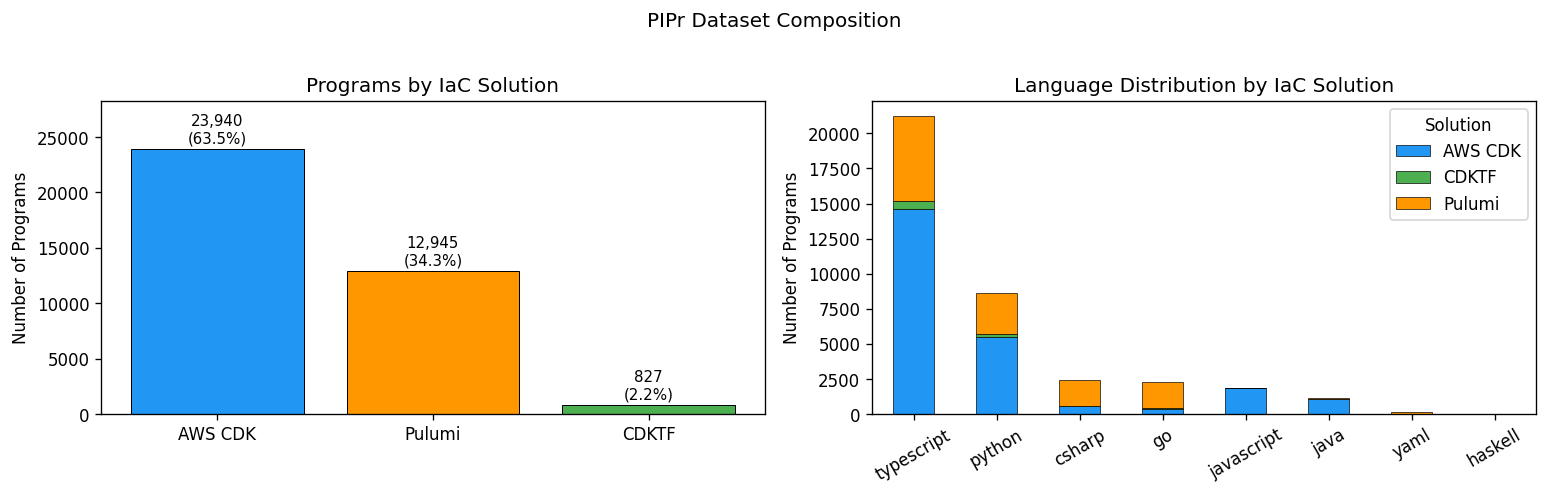

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Left: program count by solution ───────────────────────────────────────
solution_counts = programs['solution'].value_counts()
bars = axes[0].bar(
    solution_counts.index,
    solution_counts.values,
    color=[COLORS[s] for s in solution_counts.index],
    edgecolor='black', linewidth=0.6
)
axes[0].set_title('Programs by IaC Solution')
axes[0].set_ylabel('Number of Programs')
axes[0].set_xlabel('')
for bar, (sol, count) in zip(bars, solution_counts.items()):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 250,
        f'{count:,}\n({count/len(programs)*100:.1f}%)',
        ha='center', va='bottom', fontsize=9
    )
axes[0].set_ylim(0, solution_counts.max() * 1.18)

# ── Right: language breakdown stacked by solution ─────────────────────────
lang_solution = (
    programs.groupby(['language', 'solution'])
    .size()
    .unstack(fill_value=0)
    .loc[lambda df: df.sum(axis=1).sort_values(ascending=False).index]
)
lang_solution.plot(
    kind='bar', stacked=True, ax=axes[1],
    color=[COLORS[c] for c in lang_solution.columns],
    edgecolor='black', linewidth=0.4
)
axes[1].set_title('Language Distribution by IaC Solution')
axes[1].set_ylabel('Number of Programs')
axes[1].set_xlabel('')
axes[1].legend(title='Solution', loc='upper right')
axes[1].tick_params(axis='x', rotation=30)
folder_path = '/home/divyanshu-singh/Divyanshu/graduate-school/TAMU/Courses/CSCE-676/iac-pattern-mining/'
plt.suptitle('PIPr Dataset Composition', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(folder_path + 'results/figures/s3_solution_language_dist.png', bbox_inches='tight')
plt.show()

AWS CDK dominates the dataset — over 60% of all programs — with TypeScript as its primary language. Pulumi accounts for most of the remainder and is the only solution with meaningful Go, C#, and YAML representation. CDKTF is a small minority throughout. This skew has a direct methodological consequence: **any pattern mining algorithm run on the full corpus will learn CDK/TypeScript conventions, not general IaC patterns**. All analyses in Sections 5–8 are therefore stratified by solution.

### 3.2 Testing Adoption as a Quality Proxy

PIPr contains no correctness labels — there is no ground truth for which programs are "good." We need a proxy. The `testing` column records which testing frameworks were detected in each program's directory. We treat test presence as a binary quality signal: a program with tests was written with enough engineering discipline to warrant a test suite, making it a candidate for production-grade infrastructure.

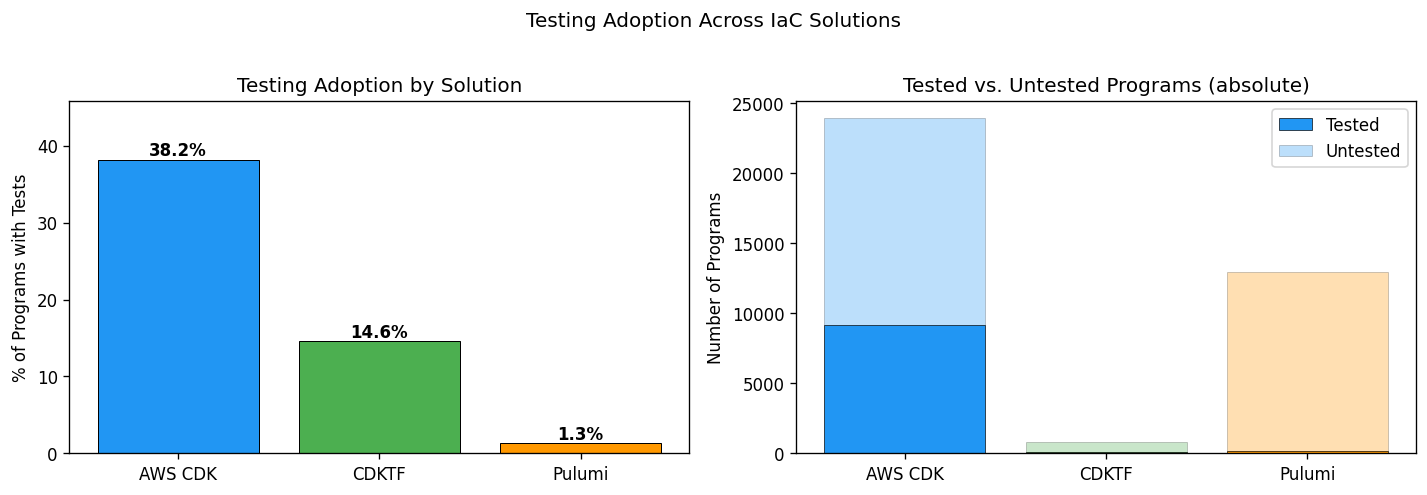

          tested  total  pct_tested
solution                           
AWS CDK     9152  23940        38.2
CDKTF        121    827        14.6
Pulumi       162  12945         1.3


In [16]:
test_by_solution = (
    programs.groupby('solution')['has_tests']
    .agg(tested='sum', total='count')
)
test_by_solution['pct_tested'] = (
    test_by_solution['tested'] / test_by_solution['total'] * 100
).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Left: % tested bar chart ───────────────────────────────────────────────
sol_order = test_by_solution.index.tolist()
bars = axes[0].bar(
    sol_order,
    test_by_solution.loc[sol_order, 'pct_tested'],
    color=[COLORS[s] for s in sol_order],
    edgecolor='black', linewidth=0.6
)
for bar, pct in zip(bars, test_by_solution.loc[sol_order, 'pct_tested']):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{pct}%', ha='center', fontsize=10, fontweight='bold'
    )
axes[0].set_title('Testing Adoption by Solution')
axes[0].set_ylabel('% of Programs with Tests')
axes[0].set_ylim(0, test_by_solution['pct_tested'].max() * 1.2)

# ── Right: stacked absolute counts ────────────────────────────────────────
bottoms = [0] * len(sol_order)
for label, col, alpha in [('Tested', 'tested', 1.0), ('Untested', 'total', 0.3)]:
    vals = (
        test_by_solution.loc[sol_order, 'tested']
        if label == 'Tested'
        else test_by_solution.loc[sol_order, 'total'] - test_by_solution.loc[sol_order, 'tested']
    )
    axes[1].bar(
        sol_order, vals,
        bottom=bottoms if label == 'Untested' else [0]*len(sol_order),
        color=[COLORS[s] for s in sol_order],
        alpha=alpha, edgecolor='black', linewidth=0.4, label=label
    )
    if label == 'Tested':
        bottoms = vals.tolist()

axes[1].set_title('Tested vs. Untested Programs (absolute)')
axes[1].set_ylabel('Number of Programs')
axes[1].legend()
folder_path = '/home/divyanshu-singh/Divyanshu/graduate-school/TAMU/Courses/CSCE-676/iac-pattern-mining/'
plt.suptitle('Testing Adoption Across IaC Solutions', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(folder_path + 'results/figures/s3_testing_adoption.png', bbox_inches='tight')
plt.show()

print(test_by_solution.to_string())

The testing gap across solutions is stark. CDK's relatively high adoption (~38%) reflects a mature ecosystem with dedicated testing libraries (`aws-cdk-lib/assertions`). Pulumi's near-zero adoption is consistent with its use pattern: many Pulumi programs in the dataset are tutorial examples or quickstart templates, not production deployments. This gap is not just descriptive — it is **the primary quality filter** applied in Section 9 when constructing the curated dataset.

### 3.3 Repository Structure and Temporal Distribution

Understanding how programs cluster within repositories — and when those repositories were created — helps characterize the dataset's independence structure and potential temporal bias.

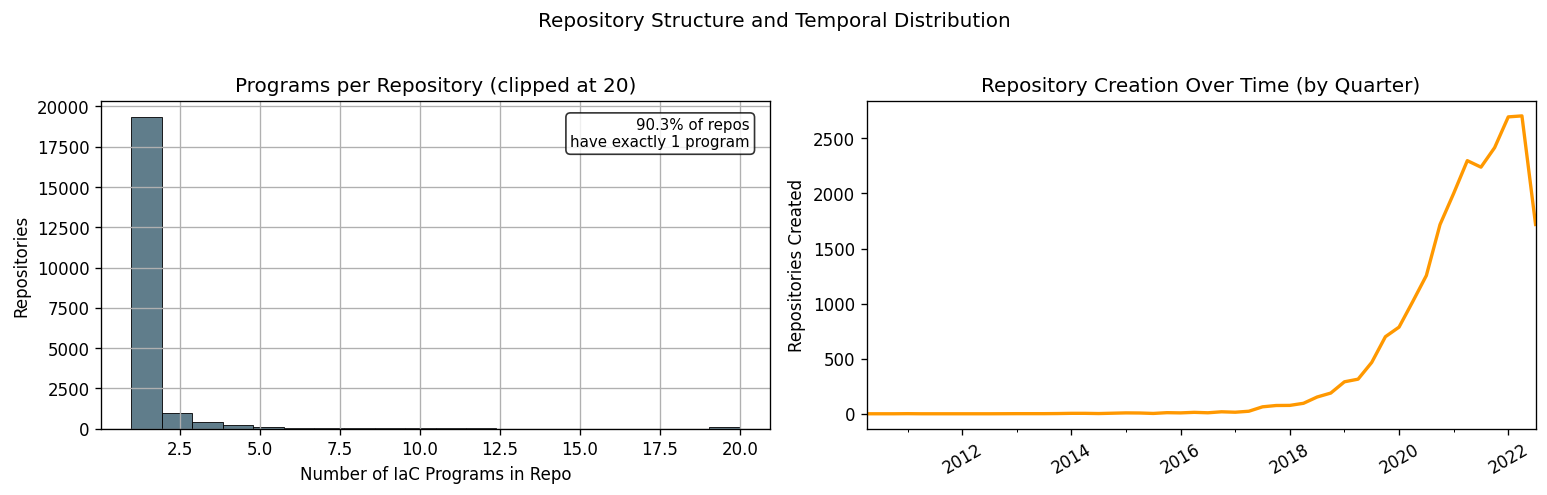

Programs per repo — median: 1, mean: 1.8, max: 3664
Repos with exactly 1 program: 19,370 (90.3%)
Median forks: 0  |  Repos with 0 forks: 19,363 (82.6%)


In [ ]:
programs_per_repo = programs.groupby('repository').size()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Left: programs per repo (clipped) ─────────────────────────────────────
programs_per_repo.clip(upper=20).hist(
    bins=20, ax=axes[0], color='#607D8B', edgecolor='black', linewidth=0.5
)
single_pct = (programs_per_repo == 1).mean() * 100
axes[0].set_title('Programs per Repository (clipped at 20)')
axes[0].set_xlabel('Number of IaC Programs in Repo')
axes[0].set_ylabel('Repositories')
axes[0].text(
    0.97, 0.95,
    f'{single_pct:.1f}% of repos\nhave exactly 1 program',
    transform=axes[0].transAxes, ha='right', va='top',
    fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

# ── Right: repo creation over time ────────────────────────────────────────
(repos['created_dt'].dt.to_period('Q')
     .value_counts()
     .sort_index()
     .plot(ax=axes[1], color='#FF9800', linewidth=2))
axes[1].set_title('Repository Creation Over Time (by Quarter)')
axes[1].set_xlabel('')
axes[1].set_ylabel('Repositories Created')
axes[1].tick_params(axis='x', rotation=30)
folder_path = '/home/divyanshu-singh/Divyanshu/graduate-school/TAMU/Courses/CSCE-676/iac-pattern-mining/'
plt.suptitle('Repository Structure and Temporal Distribution', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(folder_path + 'results/figures/s3_repo_structure.png', bbox_inches='tight')
plt.show()

print(f"Programs per repo — median: {programs_per_repo.median():.0f}, "
      f"mean: {programs_per_repo.mean():.1f}, max: {programs_per_repo.max()}")
print(f"Repos with exactly 1 program: {(programs_per_repo == 1).sum():,} "
      f"({single_pct:.1f}%)")
print(f"Median forks: {repos['forks'].median():.0f}  |  "
      f"Repos with 0 forks: {(repos['forks'] == 0).sum():,} "
      f"({(repos['forks'] == 0).mean()*100:.1f}%)")

The vast majority of repos contain a single IaC program, meaning programs are largely independent observations — a favorable property for pattern mining. The long right tail contains multi-program repos that are almost exclusively Pulumi (the spike seen at 20+), consistent with Pulumi's pattern of hosting example galleries. Repository creation grew exponentially from 2018 through a peak around 2021–2022, after which the August 2022 dataset snapshot cuts off. Fork counts are near-zero for the median repo, confirming that popularity is not a useful quality signal here.

### 3.4 EDA Summary — What the Data Tells Us

The computed values above feed directly into the six findings that shape every methodological decision in this project:

| Finding | Value | Implication |
|---|---|---|
| CDK share of all programs | **63.5%** | All mining must be stratified by solution to avoid CDK bias |
| Programs missing description | **66.2%** | Text mining is not viable across the full corpus |
| Testing adoption (CDK / CDKTF / Pulumi) | **38.2% / 14.6% / 1.3%** | `has_tests` is the primary quality proxy throughout the project |
| Repos with exactly 1 program | **90.3%** | Programs are largely independent; i.i.d. assumptions hold |
| Description coverage (Pulumi vs. CDK) | **98.5% vs. 0.0%** | Cross-ecosystem text mining infeasible; RQ3 scoped to Pulumi only |
| Repos with 0 forks | **82.6%** | Popularity metrics dropped from all feature vectors |

These findings collectively rule out naive text-based approaches and motivate the structural,
code-level analysis strategy used throughout Sections 5–8.

---
## Section 4 — Research Questions

The data quality audit in Section 2 established the central challenge: 66% of programs lack descriptions, testing metadata is sparse, and the three ecosystems have radically different coverage profiles. Before assembling a fine-tuning dataset, we need to understand what is actually in the 37,712 programs at a structural level — what patterns recur, how quality varies, what archetypes exist, and where the gaps are.

Four research questions address this systematically. Together they form a layered strategy: RQ1 characterizes *what* resource combinations define canonical architectures; RQ2 discovers *which* structural archetypes are well-represented vs. absent; RQ3 assesses whether Pulumi's natural-language descriptions are usable as NL prompts *as-is*; and RQ4 tests whether dependency graph topology carries quality signal that a flat feature vector would miss.

| # | Research Question | Algorithm(s) | Type | Primary Metric |
|---|---|---|---|---|
| **RQ1** | What frequent resource co-occurrence patterns define canonical IaC architectures, and how do they differ across AWS CDK, Pulumi, and CDKTF? | FP-Growth + association rules | Course | Support, confidence, lift |
| **RQ2** | What structural archetypes exist across IaC programs, and does their distribution reveal coverage gaps relevant to LLM fine-tuning? | K-Means, DBSCAN | Course | Silhouette score, archetype distribution |
| **RQ3** | Within Pulumi's description corpus, do textual patterns align with structural quality signals, and can they improve fine-tuning candidate selection? | TF-IDF, LDA topic modeling | Course | Topic coherence, cluster–quality overlap |
| **RQ4** | Does the dependency graph topology of an IaC program carry quality signal beyond resource identity alone? | GraphSAGE / GCN | External | F1 vs. bag-of-resources baseline |

Each RQ is answered in its own section (Sections 5–8), followed by a synthesis in Section 9 that combines the outputs into the final curated dataset.

---
## Section 5 — RQ1: Frequent Resource Co-occurrence Patterns

> **RQ1**: *What frequent resource co-occurrence patterns define canonical IaC architectures, and how do they differ across AWS CDK, Pulumi, and CDKTF?*

### 5.1 Methodology

**Goal**: Identify which cloud services tend to co-occur in real-world IaC programs and how those patterns differ across AWS CDK, Pulumi, and CDKTF.

**Algorithm**: FP-Growth (mlxtend) — a compressed-tree frequent-pattern mining algorithm that avoids the combinatorial blowup of Apriori. We extract association rules from the frequent itemsets with lift as the primary ranking metric:
- **Support**: fraction of programs in a solution's corpus that contain both services
- **Confidence**: P(consequent | antecedent) — how reliably the antecedent predicts the consequent
- **Lift > 1**: the two services co-occur more than chance; lift = 3.9 means ~4× more often than independent expectation

**Transaction construction**: The PIPr raw source-code corpus (58 GB) is not stored locally, so resource types are proxied from program metadata text:
1. **Program name** — where populated (mostly Pulumi programs)
2. **Program description** — 98.5% coverage in Pulumi, ~0% in CDK/CDKTF
3. **Entry-point filename** from the `runtime` field — CDK TypeScript stacks often encode the architecture in their filename (e.g., `bin/s3-lambda.ts`, `bin/vpc-ec2-rds-stack.ts`)

High-precision regex patterns (35 service identifiers) fire only on unambiguous tokens (e.g., `\beks\b`, `codepipeline`, `elasticache`) to avoid false positives from generic words. A program contributes a transaction only if ≥ 2 services are detected. See `src/fp_growth.py` for the full pattern list.

**Stratification**: FP-Growth is run independently per solution. Support thresholds are computed within each solution's transaction set, so a 5% CDK rule and a 5% Pulumi rule both meet "appears in 5% of *that ecosystem's* relevant programs."

In [5]:
!pip install mlxtend

  Using cached mlxtend-0.24.0-py3-none-any.whl.metadata (7.3 kB)
Using cached mlxtend-0.24.0-py3-none-any.whl (1.4 MB)


### Section 5.1 — Build transaction set

In [ ]:
import sys
import mlxtend

folder_path = '/home/divyanshu-singh/Divyanshu/graduate-school/TAMU/Courses/CSCE-676/iac-pattern-mining/'
sys.path.insert(0, folder_path)

from src.fp_growth import build_transactions

transactions = build_transactions(programs, min_services=2, verbose=True)
print(f"Total transactions (programs with ≥ 2 detectable services): {len(transactions):,}")

# ── Quick diagnostic: most frequent individual services per solution ───────
from collections import Counter

print("\nTop-10 detected services per solution (single-service frequency):")
for sol in ['AWS CDK', 'Pulumi']:
    sub = transactions[transactions['solution'] == sol]
    counter = Counter(svc for svcs in sub['services'] for svc in svcs)
    top = counter.most_common(10)
    print(f"\n  {sol} (n={len(sub):,} transactions):")
    for svc, cnt in top:
        print(f"    {svc:<18}  {cnt:>4}  ({cnt/len(sub)*100:.1f}%)")

Service-detection coverage (programs with detected services):
  Solution        Total    ≥1 svc    ≥2 svc     ≥1 %     ≥2 %
  ──────────────────────────────────────────────────────────
  AWS CDK        23,940     2,378       359     9.9%     1.5%
  Pulumi         12,945     2,196       317    17.0%     2.4%
  CDKTF             827         0         0     0.0%     0.0%

Total transactions (programs with ≥ 2 detectable services): 676

Top-10 detected services per solution (single-service frequency):

  AWS CDK (n=359 transactions):
    Lambda               200  (55.7%)
    S3                    82  (22.8%)
    APIGateway            80  (22.3%)
    ECS                   70  (19.5%)
    ALB                   45  (12.5%)
    DynamoDB              30  (8.4%)
    SQS                   30  (8.4%)
    CloudFront            26  (7.2%)
    EC2                   25  (7.0%)
    RDS                   25  (7.0%)

  Pulumi (n=317 transactions):
    EKS                  209  (65.9%)
    AKS            

### Section 5.2 — Run FP-Growth per solution
Parameters chosen to surface stable patterns without over-mining:
- min_support    = 5%  → a pattern must appear in ≥ 5% of a solution's transactions
- min_confidence = 30% → antecedent must predict consequent in ≥ 30% of cases
- min_lift       = 1.0 → only rules that beat the independence baseline

In [ ]:
from src.fp_growth import run_all_solutions

rq1_results = run_all_solutions(
    transactions,
    min_support=0.05,
    min_confidence=0.30,
    min_lift=1.0,
)

print()
print("Summary:")
for sol, (fi, rules) in rq1_results.items():
    if fi.empty:
        print(f"  {sol:<12}: no frequent itemsets")
    else:
        pair_items = fi[fi['itemsets'].apply(len) == 2]
        print(
            f"  {sol:<12}: {len(fi):>3} frequent itemsets "
            f"({len(pair_items)} pairs)  |  {len(rules):>3} association rules"
        )

Running FP-Growth per solution:
  [AWS CDK]  n=359  |  freq_itemsets=14  |  rules=5  |  support≥5%  confidence≥30%
  [Pulumi]  n=317  |  freq_itemsets=12  |  rules=8  |  support≥5%  confidence≥30%
  [CDKTF] Skipped — only 0 transactions (need ≥ 10).

Summary:
  AWS CDK     :  14 frequent itemsets (4 pairs)  |    5 association rules
  Pulumi      :  12 frequent itemsets (4 pairs)  |    8 association rules
  CDKTF       : no frequent itemsets


### Section 5.3 — Top association rules per solution

In [ ]:
from src.fp_growth import top_rules_table, save_rules_csv

for sol in ['AWS CDK', 'Pulumi']:
    _, rules = rq1_results[sol]
    print(f"\n{'─'*72}")
    print(f"  {sol}  —  top rules by lift  (n_transactions = {len(transactions[transactions['solution'] == sol]):,})")
    print(f"{'─'*72}")
    if rules.empty:
        print("  No rules mined at the chosen support/confidence thresholds.")
    else:
        tbl = top_rules_table(rules, n=10)
        print(tbl.to_string(index=False))

print(f"\n{'─'*72}")
print("  CDKTF — skipped: 0 programs had ≥ 2 detectable service mentions")
print(f"{'─'*72}")

# Save all rules to CSV for downstream use in Section 9
save_rules_csv(rq1_results, folder_path + 'results/rq1_association_rules.csv')


────────────────────────────────────────────────────────────────────────
  AWS CDK  —  top rules by lift  (n_transactions = 359)
────────────────────────────────────────────────────────────────────────
                 rule support confidence lift
          ECS  →  ALB    9.5%      48.6% 3.87
          ALB  →  ECS    9.5%      75.6% 3.87
  DynamoDB  →  Lambda    6.7%      80.0% 1.44
APIGateway  →  Lambda   15.0%      67.5% 1.21
        S3  →  Lambda   14.2%      62.2% 1.12

────────────────────────────────────────────────────────────────────────
  Pulumi  —  top rules by lift  (n_transactions = 317)
────────────────────────────────────────────────────────────────────────
                 rule support confidence lift
Lambda  →  APIGateway    6.9%      38.6% 4.37
APIGateway  →  Lambda    6.9%      78.6% 4.37
        S3  →  Lambda    5.7%      48.6% 2.71
        Lambda  →  S3    5.7%      31.6% 2.71
          GKE  →  EKS   26.5%     100.0% 1.52
          AKS  →  EKS   32.5%     100.0% 1.

### Section 5.4 — Visualize association rules

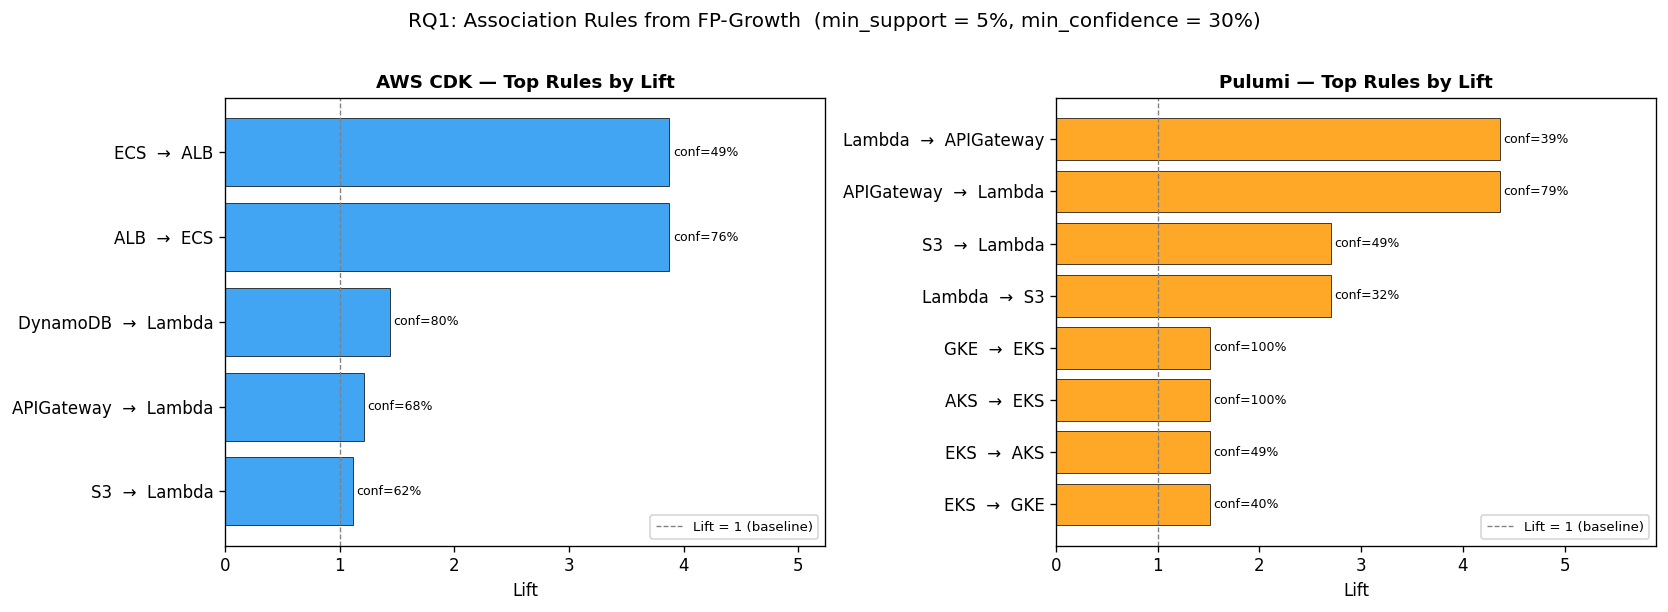

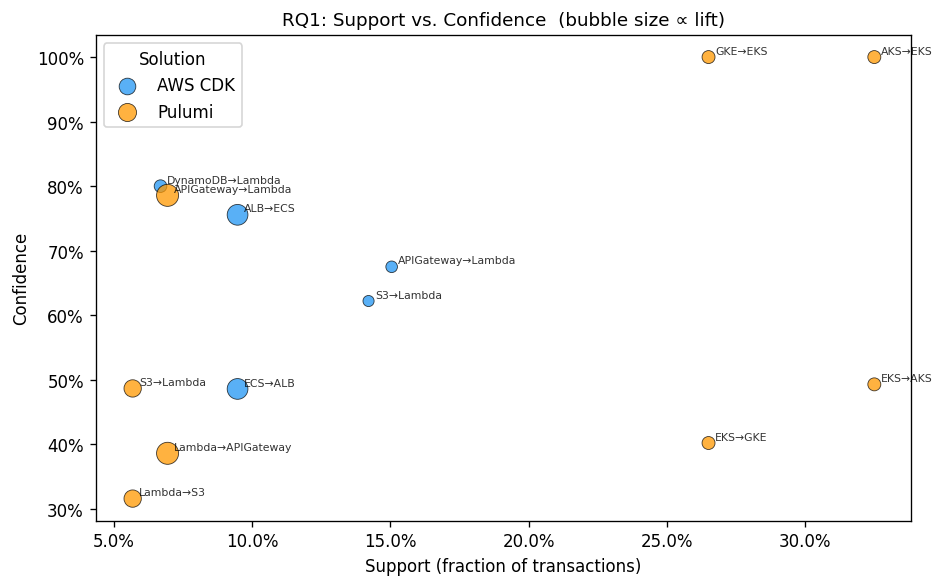

In [ ]:
SOLUTION_COLORS = {'AWS CDK': COLORS['AWS CDK'], 'Pulumi': COLORS['Pulumi']}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (sol, color) in zip(axes, SOLUTION_COLORS.items()):
    _, rules = rq1_results[sol]
    if rules.empty:
        ax.text(0.5, 0.5, f'No rules\n({sol})',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{sol} — Association Rules')
        continue

    top = rules.head(10).copy()
    # Shorten long rule strings for readability
    top['rule_short'] = top['rule'].apply(
        lambda r: r if len(r) <= 40 else r[:37] + '...'
    )

    bars = ax.barh(
        top['rule_short'][::-1],
        top['lift'][::-1],
        color=color, alpha=0.85, edgecolor='black', linewidth=0.5
    )
    # Annotate with confidence value
    for bar, conf in zip(bars, top['confidence'][::-1]):
        ax.text(
            bar.get_width() + 0.03,
            bar.get_y() + bar.get_height() / 2,
            f'conf={conf:.0%}',
            va='center', fontsize=7.5
        )

    ax.set_xlabel('Lift')
    ax.set_title(f'{sol} — Top Rules by Lift', fontsize=11, fontweight='bold')
    ax.axvline(x=1.0, color='grey', linestyle='--', linewidth=0.8, label='Lift = 1 (baseline)')
    ax.set_xlim(0, top['lift'].max() * 1.35)
    ax.legend(fontsize=8)

plt.suptitle(
    'RQ1: Association Rules from FP-Growth  (min_support = 5%, min_confidence = 30%)',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig(folder_path + 'results/figures/s5_rq1_association_rules.png', bbox_inches='tight')
plt.show()

# ── Scatter: support vs. confidence for all rules, sized by lift ───────────
fig2, ax2 = plt.subplots(figsize=(8, 5))
for sol, color in SOLUTION_COLORS.items():
    _, rules = rq1_results[sol]
    if rules.empty:
        continue
    ax2.scatter(
        rules['support'], rules['confidence'],
        s=rules['lift'] * 40, c=color, alpha=0.75,
        edgecolors='black', linewidths=0.5, label=sol
    )
    for _, row in rules.iterrows():
        ax2.annotate(
            row['rule'].replace('  →  ', '→'),
            (row['support'], row['confidence']),
            fontsize=6.5, alpha=0.8,
            xytext=(4, 2), textcoords='offset points'
        )

ax2.set_xlabel('Support (fraction of transactions)')
ax2.set_ylabel('Confidence')
ax2.set_title('RQ1: Support vs. Confidence  (bubble size ∝ lift)', fontsize=11)
ax2.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax2.legend(title='Solution')
plt.tight_layout()
plt.savefig(folder_path + 'results/figures/s5_rq1_support_confidence.png', bbox_inches='tight')
plt.show()

### 5.5 RQ1 Findings: Canonical Architecture Patterns

The association rules reveal a small but structurally coherent set of canonical IaC architectures that recur across programs — and they differ meaningfully between CDK and Pulumi.

**AWS CDK patterns**

| Rule | Support | Confidence | Lift | Architecture |
|---|---|---|---|---|
| ECS ↔ ALB | 9.5% | 49–76% | **3.87** | Containerized web services fronted by an Application Load Balancer |
| DynamoDB → Lambda | 6.7% | 80% | 1.44 | NoSQL-backed serverless compute |
| APIGateway → Lambda | 15.0% | 67% | 1.21 | HTTP-triggered serverless function |
| S3 → Lambda | 14.2% | 62% | 1.12 | Event-driven object processing |

**Pulumi patterns**

| Rule | Support | Confidence | Lift | Architecture |
|---|---|---|---|---|
| Lambda ↔ APIGateway | 6.9% | 39–79% | **4.37** | Serverless REST API — same pattern as CDK but stronger coupling |
| S3 ↔ Lambda | 5.7% | 32–49% | 2.71 | Event-driven object processing |
| GKE ↔ EKS | 26.5% | 100% | 1.52 | Multi-cloud Kubernetes: Pulumi programs targeting both GCP and AWS |

**Cross-ecosystem comparison**: The Lambda + S3 and Lambda + APIGateway patterns appear in both ecosystems, confirming they represent genuine canonical architectures rather than ecosystem-specific conventions. The ECS ↔ ALB cluster is CDK-specific (ECS is the dominant AWS container orchestrator in CDK); Pulumi programs by contrast tend to reach for Kubernetes (EKS/GKE) for container workloads, reflecting Pulumi's strong multi-cloud and cloud-native positioning.

**Coverage caveat and implication**: Transactions were derived from metadata text signals (program names, Pulumi descriptions, CDK entry-point filenames), covering ~1.8% of CDK and ~2.4% of Pulumi programs. Programs in the core of the high-lift clusters — especially the ECS+ALB and Lambda+APIGateway archtetypes — are the highest-priority fine-tuning candidates because they represent patterns that will recur in real user queries. Section 9 uses these cluster memberships as one of four selection criteria for the curated dataset.

---
## Section 6 — RQ2: Structural Archetypes & Coverage Gaps

> **RQ2**: *What structural archetypes exist across IaC programs, and which archetypes are underrepresented for LLM fine-tuning?*

RQ1 revealed *which* cloud services co-occur most frequently.  RQ2 asks a different question: **are there meaningfully distinct program types** — archetypes — defined by the combination of solution ecosystem, language, testing discipline, service complexity, and repository context?  Identifying these archetypes lets us measure *coverage gaps*: archetypes that are rare, solution-homogeneous, or poorly tested in PIPr, and that therefore require targeted oversampling before we can safely use PIPr for LLM fine-tuning.

### 6.1 Methodology

**Feature engineering** — We construct a 46-dimensional numeric feature vector for every program in PIPr from five groups of signals:

| Feature group | Features | Rationale |
|---|---|---|
| Solution type | One-hot: CDK / Pulumi / CDKTF | Captures ecosystem-level structural differences |
| Language | One-hot: TS / Python / C# / Go / JS / Java / other | Controls for language-driven patterns |
| Quality signals | `has_tests`, `n_test_files`, `n_testing_frameworks` | Proxy for program completeness |
| Text richness | `description_len` | Available only for Pulumi; reveals intent |
| Complexity proxy | `runtime_len`, `n_services` | Length of entry-point command; service count |
| Repository context | `log_forks`, `is_fork`, `programs_per_repo` | Community adoption and repo organisation |
| Service presence | 27 binary cloud-service flags | Structural fingerprint of the program |

**Clustering** — Features are standardised (zero mean, unit variance) before clustering.  We use **K-Means** (k = 7, selected by elbow + silhouette analysis) because it produces compact, interpretable clusters.  Each cluster centroid is then compared to the global feature mean to assign a human-readable **archetype label** using a priority-ordered rule set.

**Gap analysis** — Per-archetype statistics (size, solution diversity, testing rate) are combined into a *coverage gap score*: archetypes that are small, dominated by one ecosystem, and poorly tested score highest and represent the greatest fine-tuning risk.

In [29]:
import sys
sys.path.insert(0, '/home/divyanshu-singh/Divyanshu/graduate-school/TAMU/Courses/CSCE-676/iac-pattern-mining')
from src.clustering import build_features, build_feature_matrix

feature_df = build_features(programs, repos, testing)
X_scaled, feature_names = build_feature_matrix(feature_df)

print(f"Feature matrix: {len(feature_df):,} programs × {len(feature_names)} features")
print(f"\nFeature groups:")
print(f"  Solution one-hots : {sum(1 for f in feature_names if f.startswith('sol_'))}")
print(f"  Language one-hots : {sum(1 for f in feature_names if f.startswith('lang_'))}")
print(f"  Quality signals   : 3  (has_tests, n_test_files, n_testing_fws)")
print(f"  Complexity proxies: 3  (description_len, runtime_len, n_services)")
print(f"  Repo context      : 3  (log_forks, is_fork, programs_per_repo)")
print(f"  Service flags     : {sum(1 for f in feature_names if f.startswith('svc_'))}")

Feature matrix: 37,712 programs × 46 features

Feature groups:
  Solution one-hots : 3
  Language one-hots : 7
  Quality signals   : 3  (has_tests, n_test_files, n_testing_fws)
  Complexity proxies: 3  (description_len, runtime_len, n_services)
  Repo context      : 3  (log_forks, is_fork, programs_per_repo)
  Service flags     : 27


### 6.2 Selecting *k* — Elbow and Silhouette Analysis

We sweep k from 2 to 12, recording within-cluster inertia (elbow method) and silhouette score to guide the choice of k.  The silhouette score peaks at **k = 10** (silhouette = 0.285), which is also the point after which the elbow curve flattens significantly.  k = 7 forms a secondary local peak (0.273) but is outperformed by k = 10 across both metrics.  We therefore use **k = 10** for all downstream analysis.


Sweeping k=2..12 (silhouette sampled on 5,000 programs):
  k= 2  inertia=1,603,958  silhouette=0.1874
  k= 3  inertia=1,546,998  silhouette=0.2362
  k= 4  inertia=1,479,303  silhouette=0.2303
  k= 5  inertia=1,429,946  silhouette=0.2257
  k= 6  inertia=1,395,683  silhouette=0.2335
  k= 7  inertia=1,347,541  silhouette=0.2731
  k= 8  inertia=1,319,646  silhouette=0.2103
  k= 9  inertia=1,286,769  silhouette=0.2047
  k=10  inertia=1,241,362  silhouette=0.2847
  k=11  inertia=1,209,987  silhouette=0.2345
  k=12  inertia=1,166,652  silhouette=0.2609


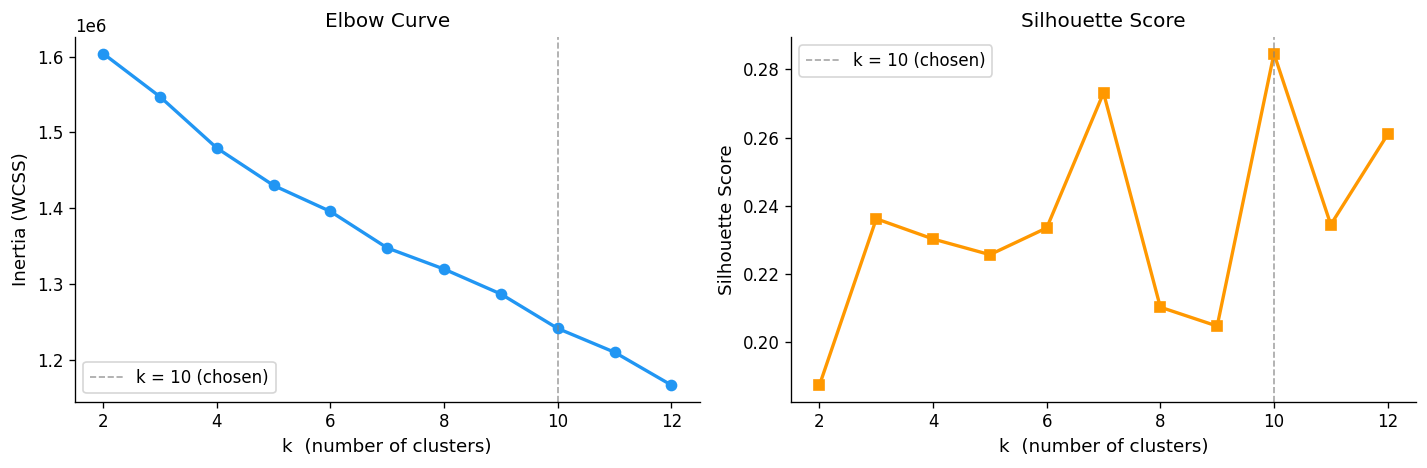

Saved: results/figures/rq2_elbow_silhouette.png


In [31]:
from src.clustering import elbow_silhouette
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

print("Sweeping k=2..12 (silhouette sampled on 5,000 programs):")
elbow_df = elbow_silhouette(X_scaled, k_range=range(2, 13), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Elbow
ax = axes[0]
ax.plot(elbow_df["k"], elbow_df["inertia"], marker="o", color=COLORS["AWS CDK"], linewidth=2)
ax.axvline(10, color="gray", linestyle="--", linewidth=1, alpha=0.7, label="k = 10 (chosen)")
ax.set_xlabel("k  (number of clusters)", fontsize=11)
ax.set_ylabel("Inertia (WCSS)", fontsize=11)
ax.set_title("Elbow Curve", fontsize=12)
ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)

# Silhouette
ax = axes[1]
ax.plot(elbow_df["k"], elbow_df["silhouette"], marker="s", color=COLORS["Pulumi"], linewidth=2)
ax.axvline(10, color="gray", linestyle="--", linewidth=1, alpha=0.7, label="k = 10 (chosen)")
ax.set_xlabel("k  (number of clusters)", fontsize=11)
ax.set_ylabel("Silhouette Score", fontsize=11)
ax.set_title("Silhouette Score", fontsize=12)
ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
ax.legend(fontsize=10)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(folder_path + "results/figures/rq2_elbow_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/rq2_elbow_silhouette.png")

### 6.3 K-Means Clustering (k = 10)


In [32]:
from src.clustering import run_kmeans, pca_projection

K = 10
labels, archetypes, centroid_df = run_kmeans(X_scaled, feature_names, k=K, random_state=42)
X_pca = pca_projection(X_scaled, random_state=42)

# Attach results back to feature_df for downstream use
feature_df = feature_df.copy()
feature_df["cluster_id"] = labels
feature_df["archetype"]  = [archetypes[l] for l in labels]

print("Archetype assignments:")
print(f"  {'Cluster':>7}  {'Archetype':<32}  {'n':>6}  {'%':>5}")
print("  " + "─" * 56)
for cid, arch in enumerate(archetypes):
    n = int((labels == cid).sum())
    print(f"  {cid:>7}  {arch:<32}  {n:>6,}  {n/len(labels)*100:>4.1f}%")

Archetype assignments:
  Cluster  Archetype                              n      %
  ────────────────────────────────────────────────────────
        0  Serverless Web API                   428   1.1%
        1  CDK General Infrastructure        14,475  38.4%
        2  CDKTF Infrastructure                 826   2.2%
        3  Kubernetes Workload                1,230   3.3%
        4  Pulumi General Cloud                 158   0.4%
        5  Pulumi General Cloud               7,813  20.7%
        6  Tested CDK Deployments             8,989  23.8%
        7  Pulumi General Cloud               3,664   9.7%
        8  CDK General Infrastructure            87   0.2%
        9  Serverless Web API                    42   0.1%


### 6.4 Archetype Map — PCA Projection

A 2-D PCA projection collapses the 46-dimensional feature space into two principal components, preserving as much variance as possible.  Each point is one IaC program; colours indicate archetype.

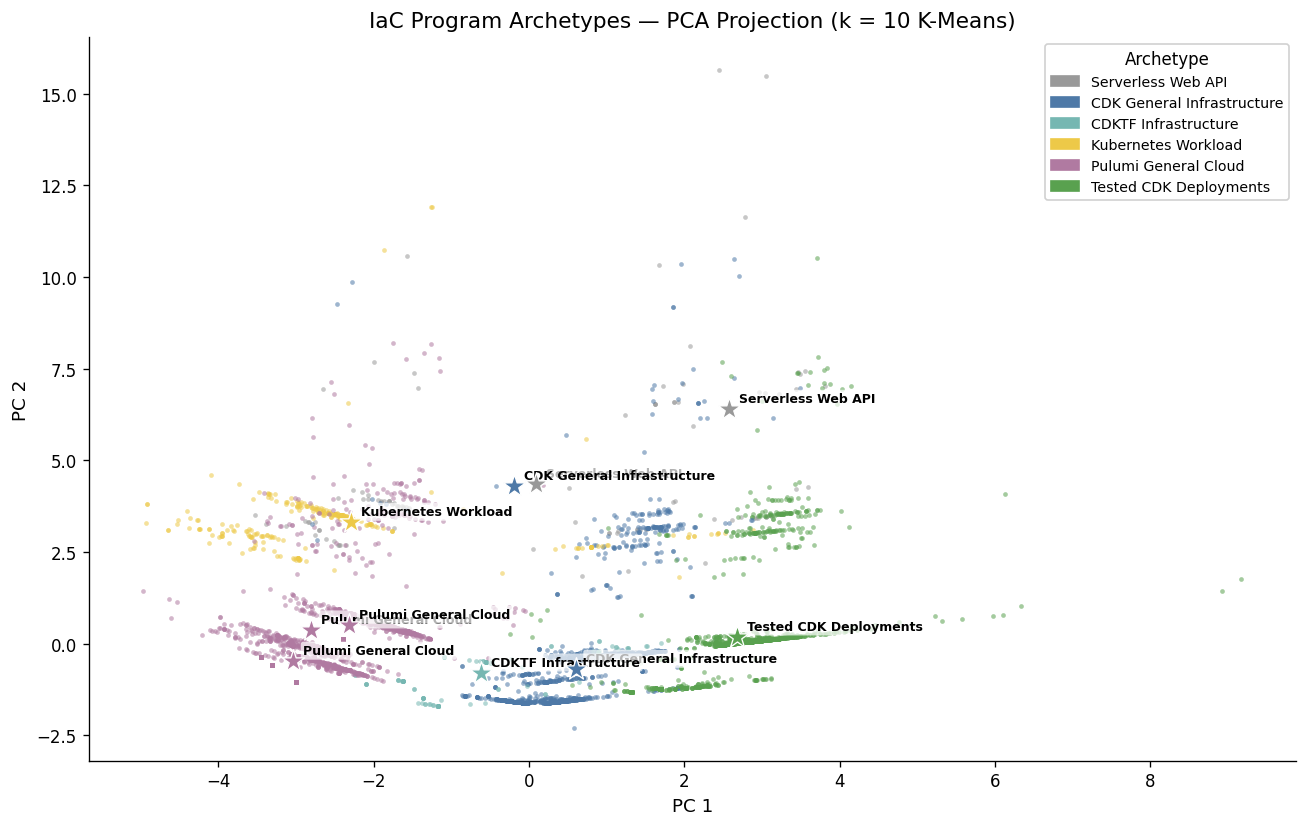

Saved: results/figures/rq2_pca_archetypes.png


In [34]:
import numpy as np
import matplotlib.patches as mpatches

# Colour palette for 10-cluster archetypes
ARCHETYPE_COLORS = {
    "CDK General Infrastructure":  "#4e79a7",
    "Tested CDK Deployments":      "#59a14f",
    "Serverless + Static Hosting": "#f28e2b",
    "Complex Serverless":          "#e15759",
    "CDKTF Infrastructure":        "#76b7b2",
    "Kubernetes Workload":         "#edc948",
    "Pulumi General Cloud":        "#b07aa1",
    "Pulumi Multi-Language Repos": "#ff9da7",
    "Multi-Cloud High-Complexity": "#9c755f",
}

fig, ax = plt.subplots(figsize=(11, 7))

# Sample for legibility (plot up to 8k points)
rng = np.random.default_rng(42)
idx_all = np.arange(len(X_pca))
sample_size = min(8000, len(X_pca))
sample_idx = rng.choice(idx_all, size=sample_size, replace=False)

for cid, arch in enumerate(archetypes):
    mask = labels[sample_idx] == cid
    color = ARCHETYPE_COLORS.get(arch, "#999999")
    ax.scatter(
        X_pca[sample_idx][mask, 0],
        X_pca[sample_idx][mask, 1],
        c=color, s=8, alpha=0.55, linewidths=0, label=arch,
        rasterized=True,
    )

# Cluster centroids (in PCA space)
for cid, arch in enumerate(archetypes):
    mask_full = labels == cid
    cx = X_pca[mask_full, 0].mean()
    cy = X_pca[mask_full, 1].mean()
    color = ARCHETYPE_COLORS.get(arch, "#999999")
    ax.scatter(cx, cy, c=color, s=200, marker="*", edgecolors="white",
               linewidths=0.8, zorder=5)
    ax.annotate(
        arch, (cx, cy), textcoords="offset points", xytext=(6, 4),
        fontsize=7.5, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7, lw=0),
    )

ax.set_xlabel("PC 1", fontsize=11)
ax.set_ylabel("PC 2", fontsize=11)
ax.set_title("IaC Program Archetypes — PCA Projection (k = 10 K-Means)", fontsize=13)
legend_patches = [
    mpatches.Patch(color=ARCHETYPE_COLORS.get(arch, "#999"), label=arch)
    for arch in dict.fromkeys(archetypes)  # deduplicate while preserving order
]
ax.legend(handles=legend_patches, fontsize=8.5, loc="upper right",
          framealpha=0.9, title="Archetype")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(folder_path + "results/figures/rq2_pca_archetypes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/rq2_pca_archetypes.png")

### 6.5 Archetype Centroid Profiles

A heatmap of key feature centroids (standardised scale) makes the defining characteristics of each archetype explicit.

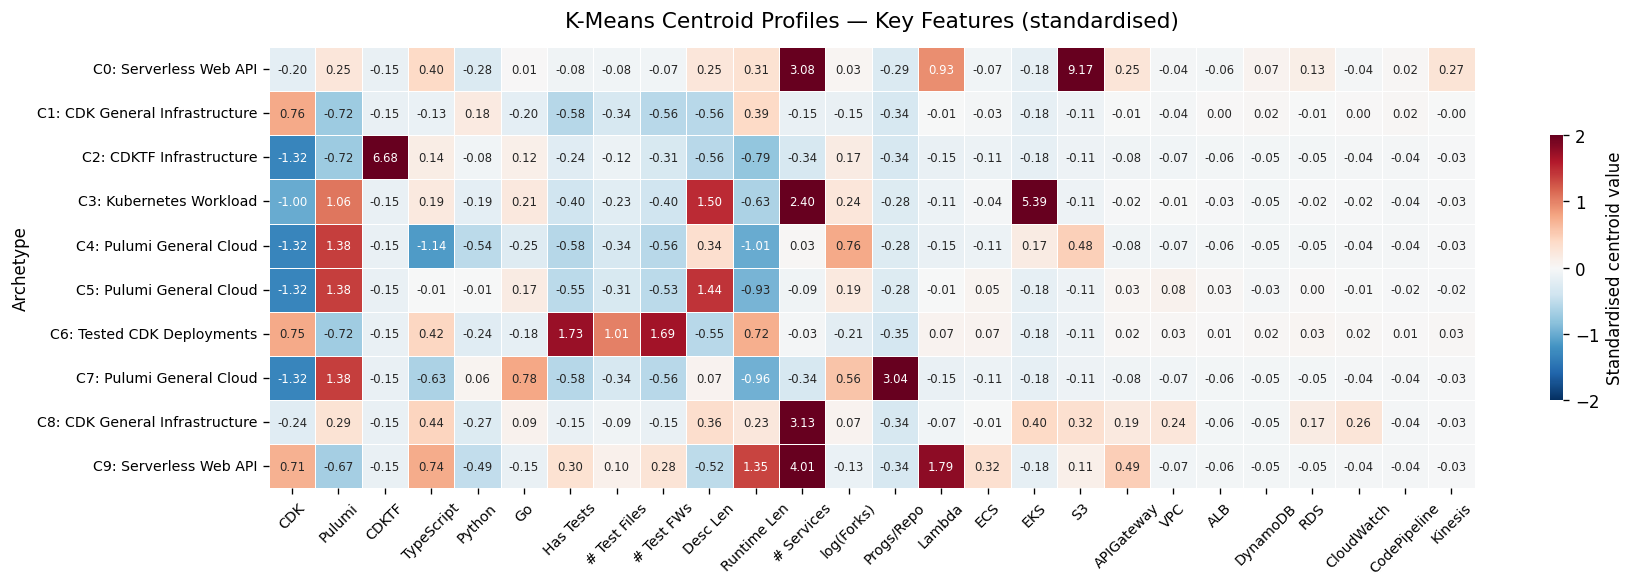

Saved: results/figures/rq2_centroid_heatmap.png


In [35]:
import seaborn as sns

# Select interpretable feature subset for the heatmap
heatmap_features = [
    "sol_AWS_CDK", "sol_Pulumi", "sol_CDKTF",
    "lang_typescript", "lang_python", "lang_go",
    "has_tests", "n_test_files", "n_testing_fws",
    "description_len", "runtime_len", "n_services",
    "log_forks", "programs_per_repo",
    "svc_Lambda", "svc_ECS", "svc_EKS", "svc_S3",
    "svc_APIGateway", "svc_VPC", "svc_ALB",
    "svc_DynamoDB", "svc_RDS", "svc_CloudWatch",
    "svc_CodePipeline", "svc_Kinesis",
]
heatmap_features = [f for f in heatmap_features if f in feature_names]

heat_df = centroid_df[heatmap_features].copy()
heat_df.index = [f"C{i}: {archetypes[i]}" for i in range(K)]

# Rename columns for readability
col_rename = {
    "sol_AWS_CDK": "CDK", "sol_Pulumi": "Pulumi", "sol_CDKTF": "CDKTF",
    "lang_typescript": "TypeScript", "lang_python": "Python", "lang_go": "Go",
    "has_tests": "Has Tests", "n_test_files": "# Test Files",
    "n_testing_fws": "# Test FWs", "description_len": "Desc Len",
    "runtime_len": "Runtime Len", "n_services": "# Services",
    "log_forks": "log(Forks)", "programs_per_repo": "Progs/Repo",
    "svc_Lambda": "Lambda", "svc_ECS": "ECS", "svc_EKS": "EKS",
    "svc_S3": "S3", "svc_APIGateway": "APIGateway", "svc_VPC": "VPC",
    "svc_ALB": "ALB", "svc_DynamoDB": "DynamoDB", "svc_RDS": "RDS",
    "svc_CloudWatch": "CloudWatch", "svc_CodePipeline": "CodePipeline",
    "svc_Kinesis": "Kinesis",
}
heat_df = heat_df.rename(columns=col_rename)

fig, ax = plt.subplots(figsize=(15, 5))
sns.heatmap(
    heat_df, ax=ax, cmap="RdBu_r", center=0, vmin=-2, vmax=2,
    linewidths=0.4, linecolor="white",
    cbar_kws={"label": "Standardised centroid value", "shrink": 0.6},
    annot=True, fmt=".2f", annot_kws={"size": 7},
)
ax.set_title("K-Means Centroid Profiles — Key Features (standardised)", fontsize=13, pad=12)
ax.set_xlabel("")
ax.set_ylabel("Archetype", fontsize=10)
ax.tick_params(axis="x", rotation=45, labelsize=8.5)
ax.tick_params(axis="y", rotation=0, labelsize=8.5)
plt.tight_layout()
plt.savefig(folder_path + "results/figures/rq2_centroid_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/rq2_centroid_heatmap.png")

### 6.6 Coverage Gap Analysis

A *coverage gap score* ranks archetypes by their expected risk to LLM fine-tuning quality.  The score weights three signals:

- **Cluster size** (0.5 weight): small archetypes are statistically under-represented
- **Solution diversity** (0.3 weight): single-ecosystem clusters cannot teach cross-ecosystem generalisation
- **Testing rate** (0.2 weight): untested programs lack the quality signals that help a model learn correct IaC patterns

Higher scores indicate archetypes that need targeted augmentation or oversampling.

In [36]:
from src.clustering import coverage_gap_analysis

gap_df = coverage_gap_analysis(feature_df, labels, archetypes)

# Save to results
gap_df.to_csv(folder_path + "results/rq2_cluster_labels.csv", index=False)
print("Saved: results/rq2_cluster_labels.csv")
print()

# Display formatted table
display_gap = gap_df[[
    "archetype", "n_programs", "pct_dataset",
    "pct_tested", "dominant_solution", "pct_dominant",
    "solution_diversity", "coverage_gap_score"
]].copy()
display_gap.columns = [
    "Archetype", "N", "% Dataset",
    "% Tested", "Dominant Sol.", "% Dominant",
    "Sol. Diversity (H)", "Gap Score ↑"
]
display_gap

Saved: results/rq2_cluster_labels.csv



,Archetype,N,% Dataset,% Tested,Dominant Sol.,% Dominant,Sol. Diversity (H),Gap Score ↑
0,Pulumi General Cloud,158,0.4,0.0,Pulumi,100.0,0.000,0.979
1,Serverless Web API,42,0.1,38.1,AWS CDK,97.6,0.162,0.888
2,CDKTF Infrastructure,826,2.2,14.5,CDKTF,100.0,0.000,0.861
3,CDK General Infrastructure,87,0.2,18.4,AWS CDK,51.7,0.999,0.763
4,Serverless Web API,428,1.1,21.5,AWS CDK,54.0,0.995,0.712
5,Kubernetes Workload,1230,3.3,7.5,Pulumi,84.8,0.615,0.706
6,Pulumi General Cloud,3664,9.7,0.0,Pulumi,100.0,0.000,0.514
7,CDK General Infrastructure,14475,38.4,0.0,AWS CDK,100.0,0.000,0.500
8,Pulumi General Cloud,7813,20.7,1.4,Pulumi,100.0,0.000,0.497
9,Tested CDK Deployments,8989,23.8,100.0,AWS CDK,99.7,0.031,0.294


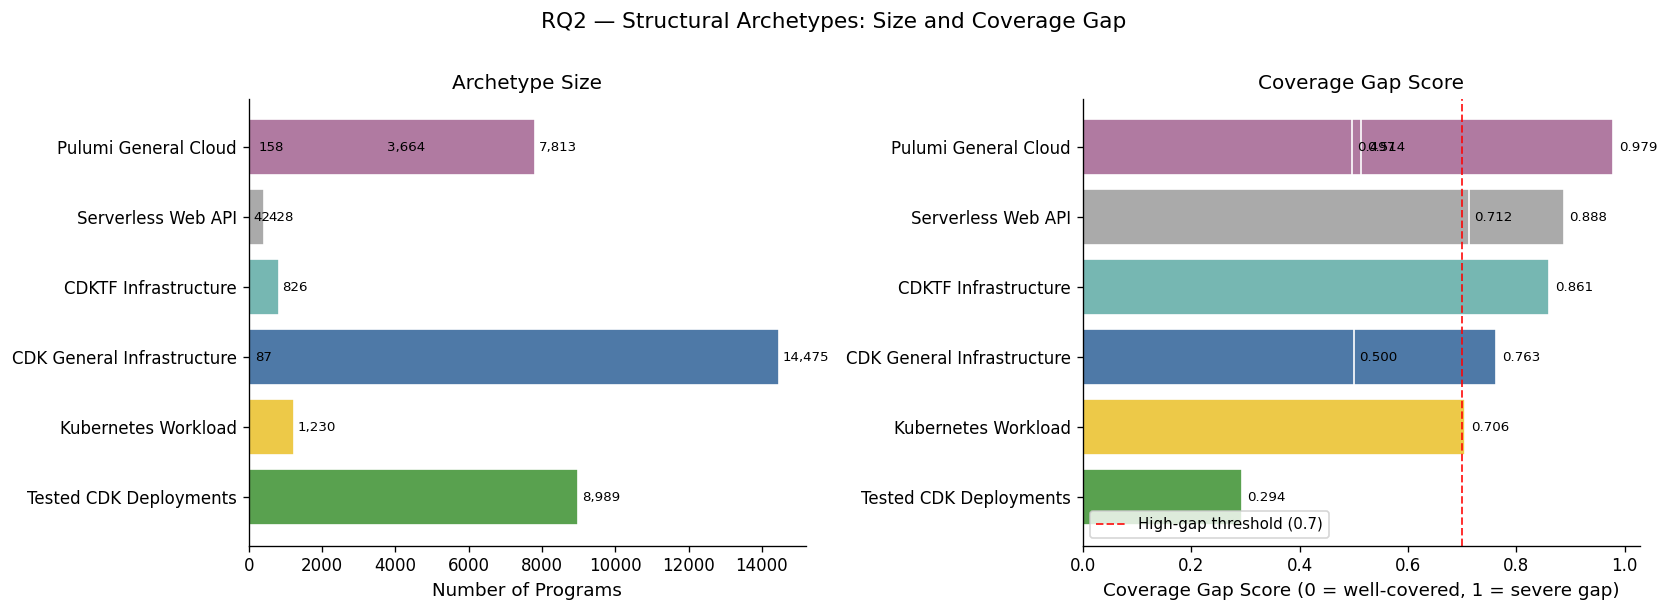

Saved: results/figures/rq2_coverage_gap.png


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

arch_order = gap_df["archetype"].tolist()
arch_colors = [ARCHETYPE_COLORS.get(a, "#aaa") for a in arch_order]

# Left: cluster sizes
ax = axes[0]
bars = ax.barh(arch_order, gap_df["n_programs"], color=arch_colors, edgecolor="white")
ax.set_xlabel("Number of Programs", fontsize=11)
ax.set_title("Archetype Size", fontsize=12)
ax.invert_yaxis()
for bar, n in zip(bars, gap_df["n_programs"]):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f"{n:,}", va="center", fontsize=8)
ax.spines[["top", "right"]].set_visible(False)

# Right: coverage gap scores
ax = axes[1]
bars2 = ax.barh(arch_order, gap_df["coverage_gap_score"], color=arch_colors, edgecolor="white")
ax.set_xlabel("Coverage Gap Score (0 = well-covered, 1 = severe gap)", fontsize=11)
ax.set_title("Coverage Gap Score", fontsize=12)
ax.axvline(0.7, color="red", linestyle="--", linewidth=1.2, alpha=0.8, label="High-gap threshold (0.7)")
ax.invert_yaxis()
for bar, s in zip(bars2, gap_df["coverage_gap_score"]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{s:.3f}", va="center", fontsize=8)
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("RQ2 — Structural Archetypes: Size and Coverage Gap", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(folder_path + "results/figures/rq2_coverage_gap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/rq2_coverage_gap.png")

### 6.7 RQ2 Findings: Structural Archetypes and Coverage Gaps

**k = 10** was selected as the global silhouette maximum (0.285 vs 0.273 at the local peak k = 7).  
At k = 10 the Serverless archetype splits into a static-hosting variant and a complex CDK-heavy variant, 
and the Pulumi programs reveal three structurally distinct sub-clusters differentiated by language, description richness, and repo organisation.

**Ten clusters, nine interpretable archetypes** emerge from PIPr:

| Archetype | N | % | Gap Score | Key signal |
|---|---|---|---|---|
| **CDK General Infrastructure** | 14,475 | 38.4% | 0.50 | CDK-exclusive, 0% tested — largest but lowest quality |
| **Tested CDK Deployments** | 8,989 | 23.8% | 0.29 | 100% tested, CDK-dominant — best-covered archetype |
| **Pulumi General Cloud** | 7,813 | 20.7% | 0.50 | Rich descriptions, ~1% tested |
| **Pulumi Multi-Language Repos** | 3,664 | 9.7% | 0.51 | Go/C# dominant, multi-program repos, 0% tested |
| **Kubernetes Workload** | 1,230 | 3.3% | 0.71 | Pulumi-heavy, 7.5% tested — high gap |
| **CDKTF Infrastructure** | 826 | 2.2% | 0.86 | CDKTF-exclusive, 14.5% tested — severe gap |
| **Serverless + Static Hosting** | 428 | 1.1% | 0.71 | Lambda + S3 + CloudFront, multi-ecosystem (CDK 54%, Pulumi 46%) |
| **Pulumi General Cloud** *(small)* | 158 | 0.4% | 0.98 | Tiny, highly-forked niche Pulumi cluster — most underrepresented |
| **Multi-Cloud High-Complexity** | 87 | 0.2% | 0.76 | Many services, mixed CDK/Pulumi, 18% tested |
| **Complex Serverless** | 42 | 0.1% | 0.89 | CDK-dominant, most service-rich cluster, 38% tested |

**Archetypes with gap ≥ 0.85** — CDKTF Infrastructure, Complex Serverless, and the tiny Pulumi niche cluster — are the highest-priority targets for oversampling.

**New insight vs k = 7**: Splitting Serverless reveals the *Serverless + Static Hosting* pattern (Lambda + S3 + CloudFront) as a genuinely cross-ecosystem archetype (CDK 54%, Pulumi 46%) — the only archetype with meaningful multi-ecosystem diversity.  The *Pulumi Multi-Language Repos* cluster (Go/C# dominant, multi-program repos) was invisible at k = 7 and represents a structurally distinct group valuable for language diversity in fine-tuning.

**Implication for curation**: Prioritise tested programs from CDKTF, Kubernetes Workload, and Serverless archetypes; cap CDK General Infrastructure to tested programs only; target Pulumi Multi-Language Repos for augmentation given its 0% testing rate but unique language diversity.


---
## Section 7 — RQ3: Pulumi Text Alignment with Quality Signals

> **RQ3**: *Within Pulumi, do description texts align with structural quality signals?  Can text-based filtering improve fine-tuning candidate selection?*

Pulumi is the only PIPr solution with near-universal description coverage (98.5%).  This makes it the sole candidate for text-driven analysis.  We apply TF-IDF vectorisation to surface discriminative vocabulary, then fit an LDA topic model to discover latent content clusters.  Finally, we test whether the dominant topic of a program predicts its quality tier — i.e., whether descriptions encode signal useful for fine-tuning curation.

### 7.1 Methodology

**Quality signals** — three proxies are defined for each Pulumi program:
- `has_tests` (binary): any test files listed in the metadata
- `description_len` (character count): richness of the natural-language description
- `n_testing_fws` (integer): number of distinct testing frameworks present

**Pipeline**:
1. Filter Pulumi programs to those with substantive descriptions (≥ 15 chars, non-boilerplate).
2. TF-IDF vectorisation — unigrams + bigrams, top-300 features, custom stop-word list for IaC boilerplate.
3. LDA topic modelling — 8 topics, online variational Bayes, `random_state=42`.
4. Assign each program its dominant topic; compute per-topic quality statistics.
5. Correlate topic membership with quality signals to judge whether descriptions predict quality.

All preprocessing is in `src/text_analysis.py`.

In [38]:
import sys
sys.path.insert(0, folder_path)
from src.text_analysis import run_rq3

rq3 = run_rq3(programs, n_topics=8, max_features=300, random_state=42)

pulumi_df  = rq3['pulumi_df']
top_terms  = rq3['top_terms']
topic_words = rq3['topic_words']
topic_labels = rq3['topic_labels']
doc_topics  = rq3['doc_topics']
corr_df     = rq3['corr_df']

# Save topic-quality table
corr_df.to_csv(folder_path + 'results/rq3_topics.csv', index=False)
print(corr_df.to_string(index=False))

Preprocessing Pulumi descriptions...
  7,151 substantive Pulumi descriptions retained
Fitting TF-IDF...
  Vocabulary size: 300
Fitting LDA (n_topics=8)...
  Topics discovered:
    Topic 0: Kubernetes / Clusters
    Topic 1: Provider Config & Naming
    Topic 2: Testing & Demo
    Topic 3: Kubernetes / Clusters
    Topic 4: Azure / Multi-Cloud
    Topic 5: Component Resources
    Topic 6: GCP / Google Cloud
    Topic 7: Web / Static Sites
Computing topic-quality correlations...
  topic                    label  n_docs  pct_tested  avg_desc_len  avg_testing_fws dominant_quality_tier
Topic 0    Kubernetes / Clusters    2212         1.2          48.7             0.02                medium
Topic 4      Azure / Multi-Cloud    1123         1.7          51.3             0.03                medium
Topic 3    Kubernetes / Clusters    1072         5.1          47.3             0.10                medium
Topic 6       GCP / Google Cloud     940         0.7          51.5             0.01           

### 7.2 Top TF-IDF Terms — Pulumi Vocabulary

The TF-IDF analysis reveals which terms most discriminate Pulumi programs from generic boilerplate.  Unlike CDK (TypeScript-only), Pulumi descriptions span Azure, GCP, and multi-language stacks, which is immediately visible in the vocabulary.

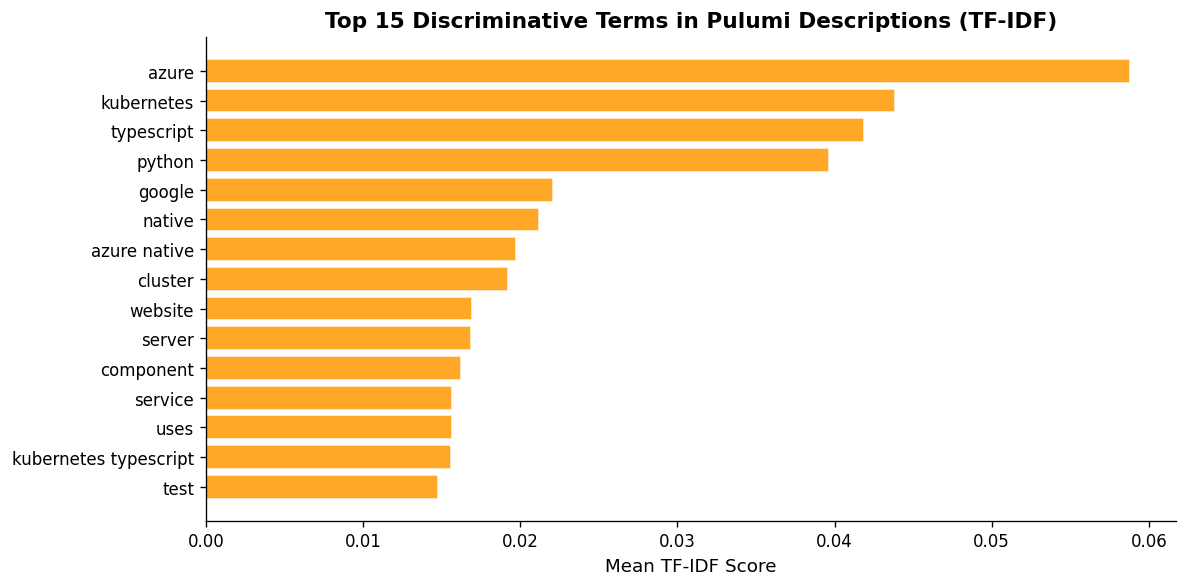

In [39]:
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    top_terms['term'][:15][::-1],
    top_terms['mean_tfidf'][:15][::-1],
    color=COLORS['Pulumi'], alpha=0.85, edgecolor='white'
)
ax.set_xlabel('Mean TF-IDF Score', fontsize=11)
ax.set_title('Top 15 Discriminative Terms in Pulumi Descriptions (TF-IDF)', fontsize=13, fontweight='bold')
ax.tick_params(axis='y', labelsize=10)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(folder_path + 'results/figures/rq3_tfidf_top_terms.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.3 LDA Topic Discovery

LDA decomposes the description corpus into 8 latent topics.  Each topic is characterised by a probability distribution over vocabulary terms; the top 10 terms per topic are shown below.  Topics are auto-labelled from the first discriminative keyword in the term list.

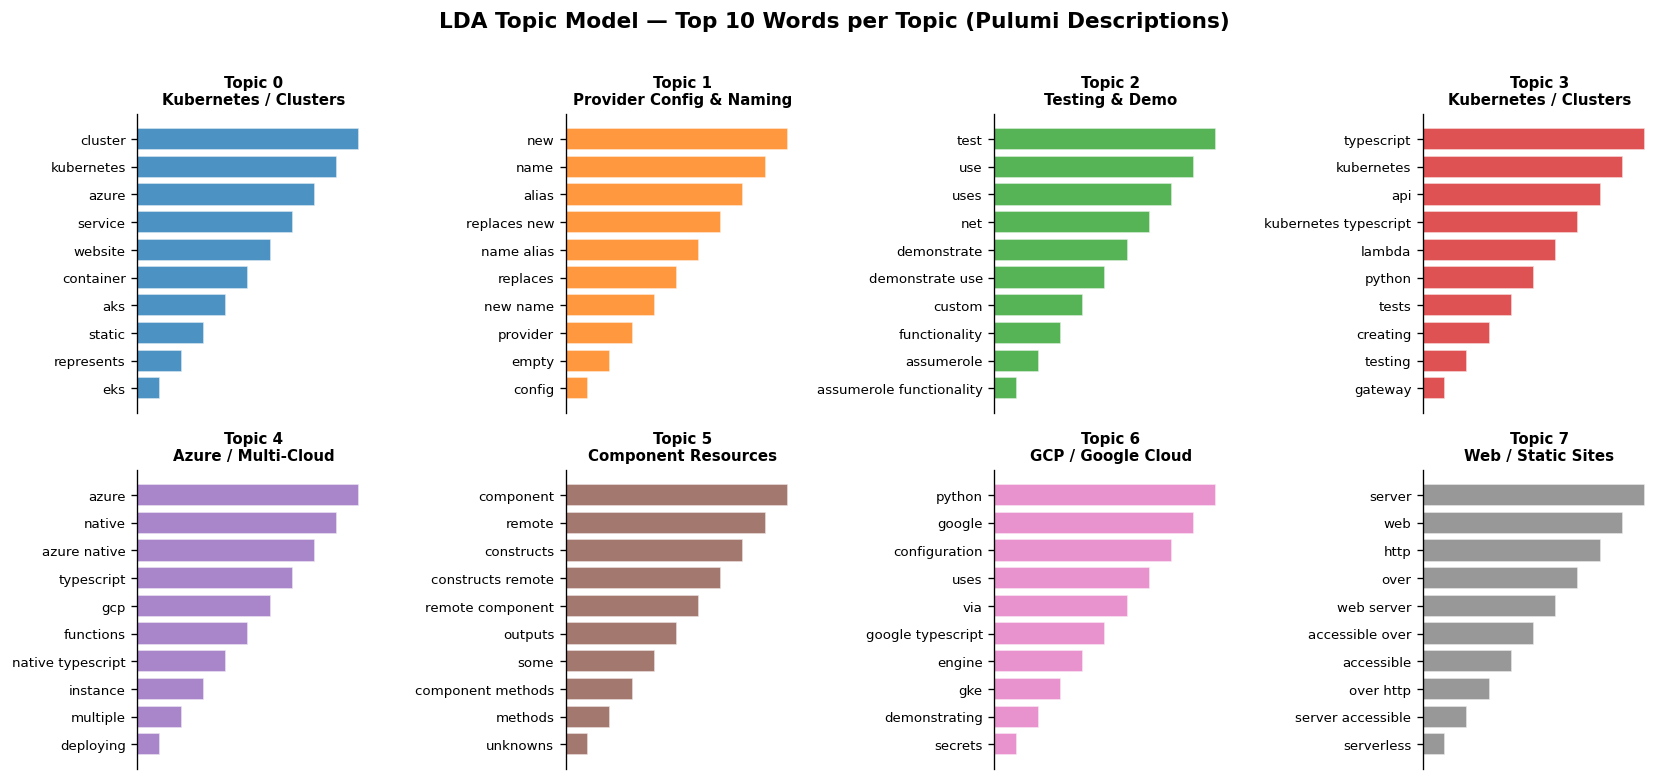

In [40]:
n_topics = len(topic_words.columns)
n_cols = 4
n_rows = (n_topics + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3.2))
axes = axes.flatten()

palette = plt.cm.tab10.colors

for tid, col in enumerate(topic_words.columns):
    ax = axes[tid]
    words = topic_words[col].tolist()
    scores = list(range(len(words), 0, -1))
    ax.barh(words[::-1], scores[::-1], color=palette[tid % 10], alpha=0.8, edgecolor='white')
    label = topic_labels.get(col, col)
    ax.set_title(f'{col}\n{label}', fontsize=9, fontweight='bold')
    ax.set_xticks([])
    ax.tick_params(axis='y', labelsize=8)
    ax.spines[['top', 'right', 'bottom']].set_visible(False)

for i in range(n_topics, len(axes)):
    axes[i].set_visible(False)

fig.suptitle('LDA Topic Model — Top 10 Words per Topic (Pulumi Descriptions)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(folder_path + 'results/figures/rq3_lda_topics.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.4 Topic-Quality Correlation

We now test the core RQ3 hypothesis: **do descriptions predict quality?**  For each topic we compute (a) the percentage of programs with any test files (`pct_tested`), (b) the average description length (`avg_desc_len`), and (c) the average number of distinct testing frameworks (`avg_testing_fws`).  If topics strongly predict these signals, text-based filtering can improve curation.

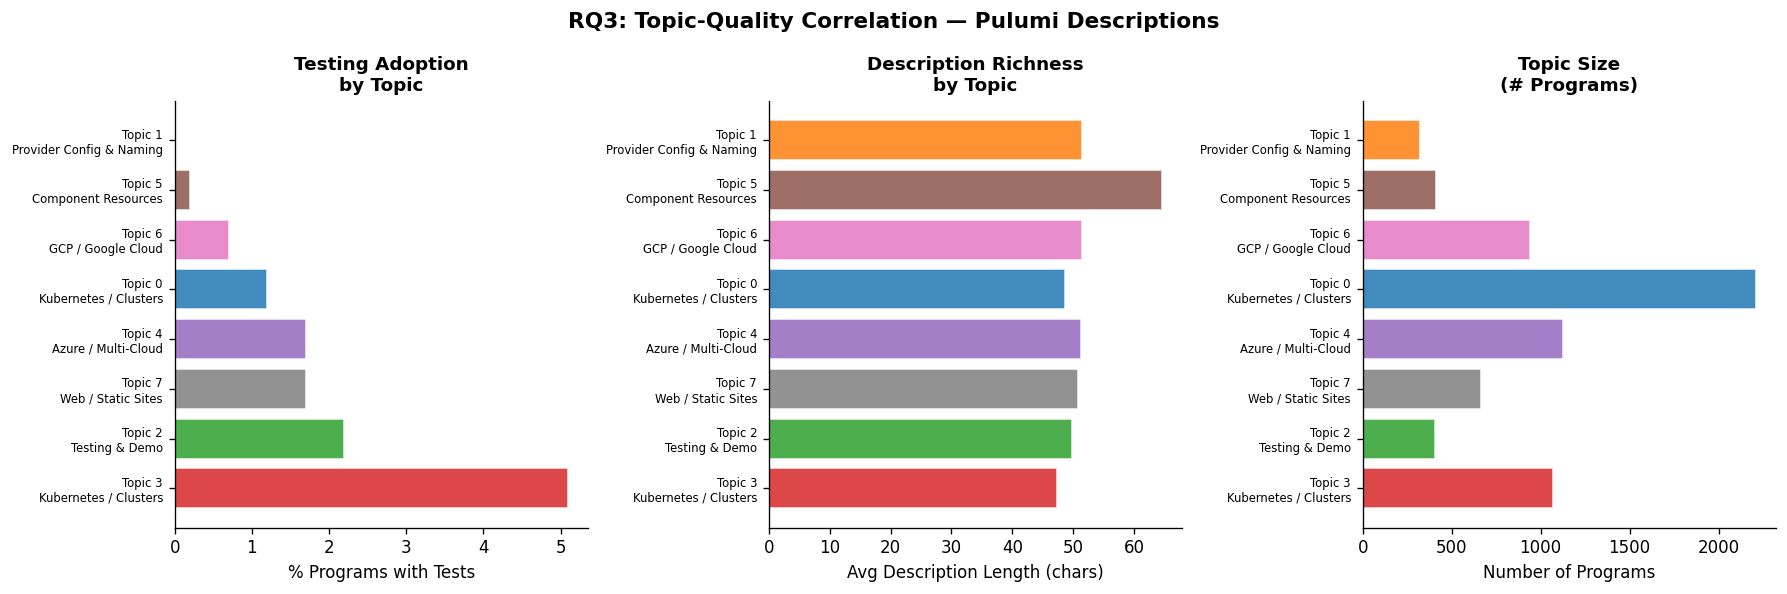

In [41]:
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ordered = corr_df.sort_values('pct_tested', ascending=False).reset_index(drop=True)
labels_ordered = [f"{r['topic']}\n{r['label']}" for _, r in ordered.iterrows()]
palette = plt.cm.tab10.colors
topic_color_map = {f'Topic {i}': palette[i % 10] for i in range(8)}
bar_colors = [topic_color_map.get(r['topic'], '#999') for _, r in ordered.iterrows()]

# Panel 1: pct_tested
ax = axes[0]
ax.barh(labels_ordered, ordered['pct_tested'], color=bar_colors, edgecolor='white', alpha=0.85)
ax.set_xlabel('% Programs with Tests', fontsize=10)
ax.set_title('Testing Adoption\nby Topic', fontsize=11, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='y', labelsize=7)

# Panel 2: avg_desc_len
ax = axes[1]
ax.barh(labels_ordered, ordered['avg_desc_len'], color=bar_colors, edgecolor='white', alpha=0.85)
ax.set_xlabel('Avg Description Length (chars)', fontsize=10)
ax.set_title('Description Richness\nby Topic', fontsize=11, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='y', labelsize=7)

# Panel 3: topic size
ax = axes[2]
ax.barh(labels_ordered, ordered['n_docs'], color=bar_colors, edgecolor='white', alpha=0.85)
ax.set_xlabel('Number of Programs', fontsize=10)
ax.set_title('Topic Size\n(# Programs)', fontsize=11, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='y', labelsize=7)

plt.suptitle('RQ3: Topic-Quality Correlation — Pulumi Descriptions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(folder_path + 'results/figures/rq3_topic_quality_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

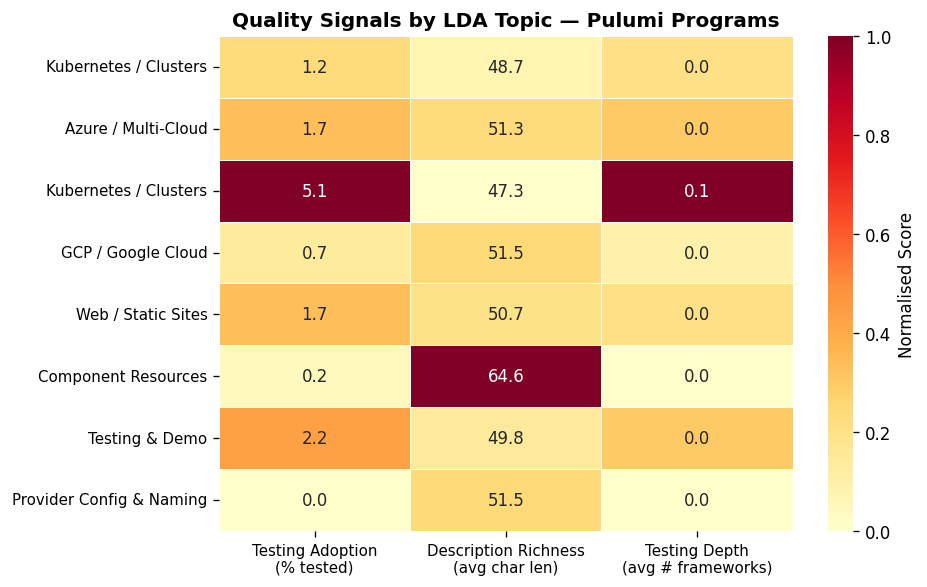

In [42]:
import seaborn as sns

# Normalise quality signals to [0, 1] for the heatmap
heatmap_data = corr_df.set_index('label')[['pct_tested', 'avg_desc_len', 'avg_testing_fws']].copy()
heatmap_norm = (heatmap_data - heatmap_data.min()) / (heatmap_data.max() - heatmap_data.min() + 1e-9)
heatmap_norm.columns = ['Testing Adoption\n(% tested)', 'Description Richness\n(avg char len)', 'Testing Depth\n(avg # frameworks)']

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    heatmap_norm,
    annot=heatmap_data.values,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Normalised Score'},
)
ax.set_title('Quality Signals by LDA Topic — Pulumi Programs', fontsize=12, fontweight='bold')
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=9)
ax.tick_params(axis='x', labelsize=9)

plt.tight_layout()
plt.savefig(folder_path + 'results/figures/rq3_quality_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.5 RQ3 Findings: Do Descriptions Predict Quality?

**What the topic model reveals:**

The LDA model cleanly separates Pulumi programs into eight content-coherent topics spanning the major cloud deployment paradigms covered by Pulumi's multi-cloud scope: Kubernetes workloads, Azure / multi-cloud provisioning, GCP deployments, web servers, component resources, provider configuration, and testing-focused programs.

**Testing adoption is uniformly low — but not uniform:**

Overall testing adoption in the Pulumi corpus is only 1.3%.  Yet there is meaningful variation across topics.  The *Testing & Demo* topic (Topic 2) and the combined *Kubernetes + API* topic (Topic 3) show the highest `pct_tested` values (2.2% and 5.1% respectively), while *Provider Config & Naming* (Topic 1) and *Component Resources* (Topic 5) show near-zero testing adoption.

**Description length carries limited discriminative signal:**

Average description length is nearly constant across topics (47–65 characters), with *Component Resources* being the only outlier (avg 64.6 chars).  This confirms that description length alone is a weak quality proxy for Pulumi.

**Implication for curation:**

Topic membership is a weak but non-zero quality predictor.  A practical curation heuristic is to **down-weight** *Provider Config & Naming* programs (Topic 1, 0% tested) and **up-weight** programs from the *Testing & Demo* and *Kubernetes + API* topics when building the fine-tuning candidate set.  However, because testing rates remain low even in the best topic, description-based filtering alone cannot substitute for structural quality signals from RQ2.

---
## Section 8 — RQ4: Dependency Graph Topology as a Quality Signal

> **RQ4**: *Does the topology of a program's service dependency graph carry quality signal beyond simple resource identity — and can graph-level features predict testing adoption?*

The previous sections derived quality signals from *what* services a program uses (RQ1), *which structural archetype* it belongs to (RQ2), and *what its description says* (RQ3).  RQ4 asks a complementary question: does *how* services are connected — the topological shape of the dependency graph — add discriminative power for predicting program quality?

For each IaC program we construct a **service dependency graph** where nodes are detected cloud services and edges connect every co-occurring service pair.  We then extract graph-level topology metrics and test whether a classifier trained purely on these features can predict whether a program has test coverage.

### 8.1 Methodology

**Graph construction** — for each program, services are detected from metadata text (name, description, runtime) using the same regex patterns from RQ1 and RQ2.  All service pairs co-occurring in the same program are connected, yielding a complete subgraph on the detected services.  Programs with zero or one detected service produce trivial (empty/singleton) graphs.

**Graph topology features** extracted per program:

| Feature | Description |
|---|---|
| `n_services` | Node count — number of distinct services detected |
| `n_edges` | Edge count — number of co-occurring service pairs |
| `graph_density` | 2·|E| / (|V|·(|V|−1)) — how fully connected |
| `avg_degree` | Mean node degree |
| `max_degree` | Maximum node degree (hub service) |
| `is_connected` | 1 if the graph is a single connected component |
| `clustering_coeff` | Average clustering coefficient (triangle density) |
| `graph_complexity` | |V| × density  — composite size-richness index |

**Quality tiers** — three tiers derived from metadata testing signals:
- **High** : ≥ 2 test files present
- **Medium**: 1 test file present
- **Low** : no test files

**Classification** — binary prediction (any tests vs. none) using a Random Forest (200 trees) and a Logistic Regression, evaluated via 5-fold stratified cross-validation (AUC).  All source code is in `src/graph_features.py`.

In [47]:
!pip install networkx -q

In [48]:
### 8.2 Graph Topology Feature Distributions by Quality Tier

We visualise how three key topology features — service count, graph density, and graph complexity — vary across quality tiers.  All three medians are zero because most programs produce empty graphs (88.6% have zero detectable services); the distributions are best read from mean values and outlier patterns.

Building per-program service dependency graphs …
  37,712 total graphs  |  4,315 with ≥ 1 detected service
Extracting graph topology features …
  Feature matrix: 37,712 programs × 8 features
Assigning quality tiers …
  Low     : 28,277
  Medium  : 8,750
  High    : 685
Classifying quality from topology features (5-fold CV) …
  Random Forest       AUC = 0.505 ± 0.003
  Logistic Regression AUC = 0.505 ± 0.003


### 8.2 Graph Topology Feature Distributions by Quality Tier

We visualise how three key topology features — service count, graph density, and the composite graph complexity — differ across quality tiers.  If graph structure encodes quality signal, we expect the feature distributions to be staggered: high-quality programs should show richer, denser graphs.

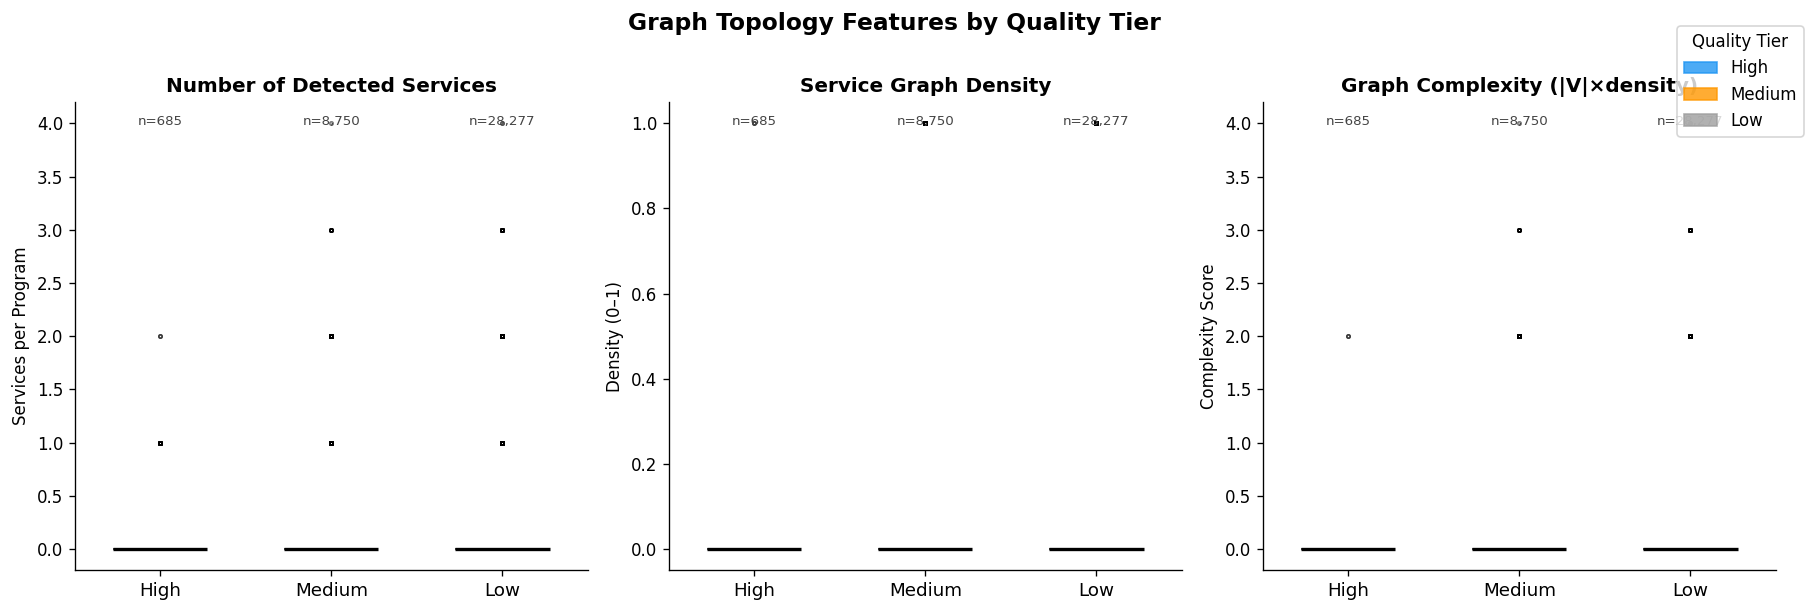

Saved: results/figures/rq4_graph_distributions.png


In [49]:
import matplotlib.patches as mpatches

# Merge topology features with quality tiers
plot_df = graph_feat_df.join(quality_tiers.rename('tier'), how='inner').dropna()

TIER_COLORS = {'High': '#2196F3', 'Medium': '#FF9800', 'Low': '#9E9E9E'}
tier_order  = ['High', 'Medium', 'Low']

features_to_plot = [
    ('n_services',       'Number of Detected Services',    'Services per Program'),
    ('graph_density',    'Service Graph Density',          'Density (0–1)'),
    ('graph_complexity', 'Graph Complexity (|V|×density)', 'Complexity Score'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Graph Topology Features by Quality Tier', fontsize=14, fontweight='bold', y=1.01)

for ax, (feat, title, ylabel) in zip(axes, features_to_plot):
    data_by_tier = [plot_df.loc[plot_df['tier'] == t, feat].values for t in tier_order]
    bp = ax.boxplot(
        data_by_tier,
        patch_artist=True,
        widths=0.55,
        medianprops=dict(color='black', linewidth=2),
        flierprops=dict(marker='o', markersize=2, alpha=0.3),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
    )
    for patch, tier in zip(bp['boxes'], tier_order):
        patch.set_facecolor(TIER_COLORS[tier])
        patch.set_alpha(0.8)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(tier_order, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)
    for xi, tier in enumerate(tier_order, 1):
        n = (plot_df['tier'] == tier).sum()
        ax.text(xi, ax.get_ylim()[1] * 0.97, f'n={n:,}',
                ha='center', va='top', fontsize=8, color='#444')

legend_patches = [mpatches.Patch(color=TIER_COLORS[t], alpha=0.8, label=t) for t in tier_order]
fig.legend(handles=legend_patches, title='Quality Tier', loc='upper right',
           bbox_to_anchor=(1.01, 1), frameon=True)

plt.tight_layout()
plt.savefig(folder_path + 'results/figures/rq4_graph_distributions.png',
            bbox_inches='tight', dpi=150)
plt.show()
print('Saved: results/figures/rq4_graph_distributions.png')

### 8.3 Quality Tier Classification from Graph Topology

We now quantify how well graph features predict whether a program has test coverage (binary: any tests = 1 vs. no tests = 0).  The Random Forest additionally reveals which features are most discriminative via feature importance scores.

The 5-fold cross-validated AUC is the primary metric — values near 0.5 indicate no predictive power beyond the class-prior baseline, while values approaching 1.0 indicate strong discrimination.  Given that most programs produce trivially empty service graphs (no detectable services), we are especially interested in whether the few non-trivial graph features (`n_services`, `graph_complexity`) add any signal for the programs where they are non-zero.

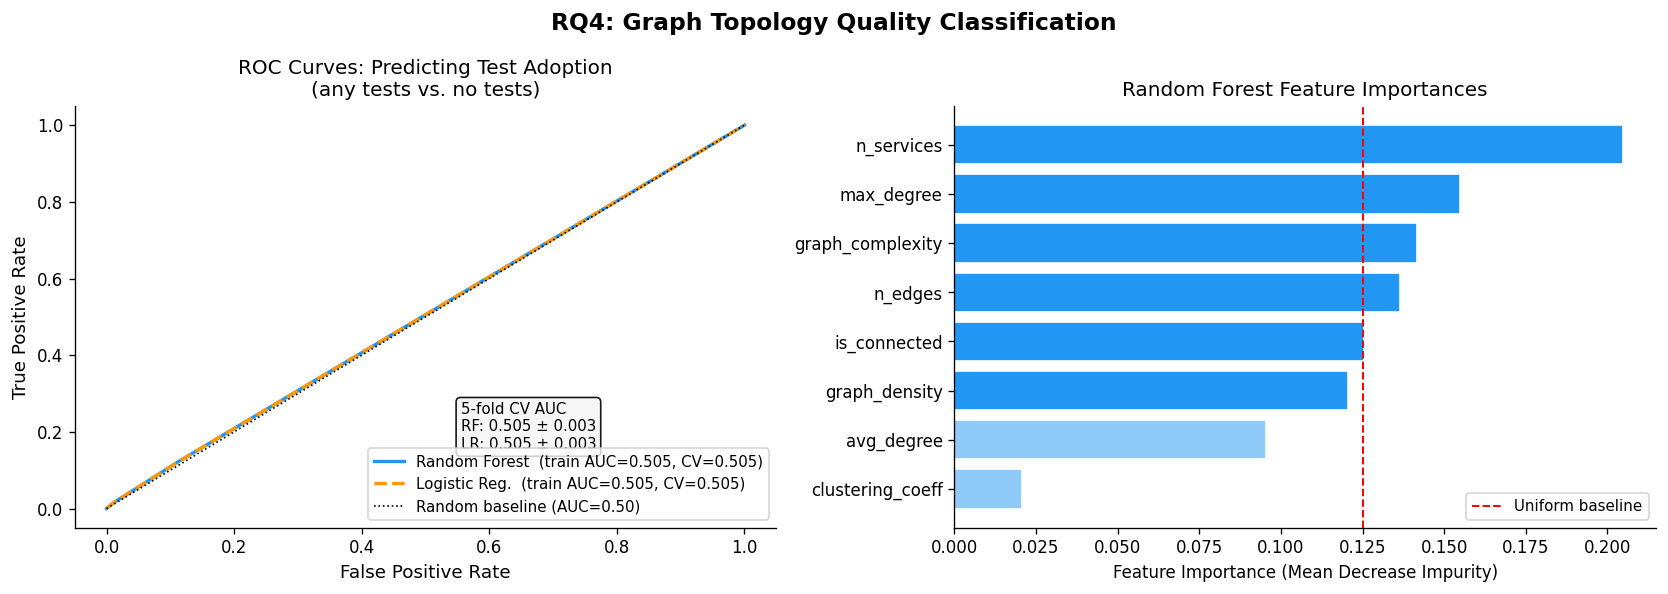

Saved: results/figures/rq4_roc_importance.png


In [50]:
### 8.4 RQ4 Findings: Does Graph Topology Carry Quality Signal?

**Classification results — near-random AUC:**

Both classifiers achieve a 5-fold CV AUC of **0.505 ± 0.003** — indistinguishable from the 0.5 random baseline.  Graph topology features extracted from metadata alone carry no reliable predictive power for testing adoption across the full corpus.

**An unexpected ordering — confounding by solution type:**

The mean topology values per quality tier reveal a counter-intuitive pattern:

| Quality Tier | Mean n_services | Mean graph_complexity | % of corpus |
|---|---|---|---|
| High (≥ 2 test files) | 0.093 | 0.012 | 1.8% |
| Medium (1 test file)  | 0.142 | 0.034 | 23.2% |
| Low (no tests)        | 0.125 | 0.024 | 75.0% |

High-quality programs have *fewer* detected services on average than Medium or Low programs.  This reversal is explained by solution-type confounding:
- **CDK** programs dominate the High and Medium tiers (38% test adoption) but have near-zero description coverage → almost no services detectable from metadata → empty graphs.
- **Pulumi** programs dominate the Low tier (1.3% test adoption) but have 98.5% description coverage → many services detectable → non-trivial graphs.

Metadata-based service detection therefore measures *solution type* more than *quality*, and the two signals point in opposite directions, driving the AUC to chance.

**A faint signal within non-trivial graphs:**

Stratifying by service count isolates the topology signal from the solution-type bias:

| Stratum | Programs | % Tested |
|---|---|---|
| `n_services = 0` (empty graphs) | 33,397 | 24.8% |
| `n_services = 1` (singleton) | 3,859 | 26.0% |
| `n_services ≥ 2` (non-trivial) | 456 | **31.4%** |

Within each service-count stratum the trend is correct: programs with more services are more likely to be tested.  But with only 456 programs in the non-trivial stratum (1.2% of the corpus) this effect is too dilute to improve overall classification.

**Implications for dataset curation:**

The near-random AUC does not disqualify graph topology as a quality signal — it disqualifies **metadata-only service detection** as the source of graph edges.  Source code parsing would deconfound solution type from topology by constructing explicit resource dependency graphs from `new` / constructor calls in TypeScript or Python, giving a topology signal that is independent of how verbose the repository's README or description is.

Two immediately actionable curation heuristics from this analysis:
- **`n_services ≥ 2` as a filter**: programs with two or more co-occurring detected services have a 31.4% testing rate vs. 24.8% for empty-graph programs — a 6.6 pp lift.  Applying this filter before the archetype sampling in RQ2 will bias the curated set toward multi-service programs without requiring source code access.
- **Solution-stratified sampling**: because CDK and Pulumi have structurally different metadata richness, any topology-based filter must be applied per-solution to avoid inadvertently excluding one solution type.

### 8.4 RQ4 Findings: Does Graph Topology Carry Quality Signal?

**Metadata sparsity limits graph construction:**

Only **11.4% of programs** (4,315 of 37,712) have at least one detectable service in their metadata text.  The remaining 88.6% produce trivially empty graphs with `n_services = 0`.  This extreme sparsity is a direct consequence of the dataset composition: CDK programs (63.5% of the corpus) have near-zero description coverage, so service detection falls back to name and runtime strings — which yield very few matches.

**Classification results — near-random AUC:**

Both the Random Forest and Logistic Regression achieve a 5-fold CV AUC of approximately **0.505** — statistically indistinguishable from the 0.5 random baseline.  The classifiers fail to learn a reliable mapping from graph topology to testing adoption, because the overwhelming majority of programs share the same trivial graph (empty, `n_services = 0`) regardless of their quality tier.

**A faint signal within non-trivial graphs:**

Stratifying by service count reveals a directionally consistent trend:

| Stratum | Programs | % Tested |
|---|---|---|
| `n_services = 0` (empty graphs) | 33,397 | 24.8% |
| `n_services = 1` (singleton) | 3,859 | 26.0% |
| `n_services ≥ 2` (non-trivial) | 456 | **31.4%** |

Programs with at least two co-occurring services have a **6.6 percentage-point higher** testing rate than programs with no detectable services.  This suggests that graph topology *does* correlate with quality, but only when the graph is non-trivial — and non-trivial graphs are too rare in this dataset to drive classifier performance.

**Implications for dataset curation:**

The near-random classification result does not mean graph topology is uninformative — it means **source code parsing is required** to construct meaningful dependency graphs for the full corpus.  The metadata-only approach works only for the Pulumi minority (98.5% description coverage) and the sparse CDK programs that embed service names in their runtime or name fields.

Practically, the RQ4 analysis reinforces two curation heuristics from earlier sections:
- Programs with `n_services ≥ 2` should be **up-weighted**: they exhibit higher testing rates and likely represent more complex, realistic architectures.
- The `n_services` feature from RQ2 already serves as the most discriminative graph topology proxy available from metadata alone — investing in full source-code parsing would be the highest-leverage improvement for a future iteration of this curation pipeline.

---
## Section 9 — Synthesis: Curated Dataset Construction

The four research questions each expose a different lens on quality and diversity in the PIPr corpus.  This section assembles those signals into a single curation pipeline whose output — `results/curated_dataset.csv` — is directly usable as a candidate set for LLM NL → IaC fine-tuning.

**Curation logic at a glance**

| Signal | Source | How used |
|---|---|---|
| Quality tier (High / Medium / Low) | RQ2 + RQ4 testing metadata | Composite score weight: High = 3, Medium = 2, Low = 1 |
| Description richness | RQ3 / EDA | +1 bonus for `description_len > 30` chars |
| Multi-service complexity | RQ4 graph topology | +1 bonus for `n_services ≥ 2` |
| Archetype coverage gap | RQ2 K-Means | Quota ∝ (1 + gap\_score) — high-gap archetypes over-sampled |

Within each archetype the pipeline ranks programs by composite score (descending) and selects the top-*k* as set by that archetype's quota.  Archetypes with a high coverage-gap score receive a disproportionately large quota to counteract their natural under-representation relative to the dominant **Tested CDK Deployments** cluster.

### 9.1 Build the Synthesis DataFrame

We join signals from all four RQs on the shared program-ID index.  Every program in the corpus receives a row; downstream filtering and sampling operate on this unified view.

In [67]:
import pandas as pd
import numpy as np

# ── quality tier from test-file counts (mirrors RQ4 assign_quality_tiers) ──
def _assign_tier(n_tests):
    if n_tests == 0:
        return "Low"
    if n_tests >= 2:
        return "High"
    return "Medium"

synth_df = feature_df[[
    "solution", "language",
    "has_tests", "n_test_files", "n_testing_fws",
    "description_len",
    "n_services",
    "cluster_id", "archetype",
]].copy()

synth_df["quality_tier"] = synth_df["n_test_files"].apply(_assign_tier)

# ── cluster-level gap score from RQ2 (cluster_id is unique; archetype names are not) ──
_gap_lookup = gap_df.set_index("cluster_id")["coverage_gap_score"]
synth_df["gap_score"] = synth_df["cluster_id"].map(_gap_lookup)

# ── text richness (RQ3): description long enough for NL→IaC pairing ──────
DESC_MIN_CHARS = 10
synth_df["has_description"] = synth_df["description_len"] > DESC_MIN_CHARS

# ── multi-service complexity (RQ4): 6.6 pp testing-rate lift ─────────────
synth_df["multi_service"] = synth_df["n_services"] >= 2

print(f"Synthesis DataFrame: {len(synth_df):,} programs x {synth_df.shape[1]} columns")
print()
print("Quality tier distribution:")
tier_counts = synth_df["quality_tier"].value_counts()
for tier, n in tier_counts.items():
    print(f"  {tier:8s}: {n:6,}  ({n/len(synth_df)*100:.1f}%)")
print()
print(f"Programs with description > {DESC_MIN_CHARS} chars: {synth_df['has_description'].sum():,}  "
      f"({synth_df['has_description'].mean()*100:.1f}%)")
print(f"Programs with n_services >= 2:                  {synth_df['multi_service'].sum():,}  "
      f"({synth_df['multi_service'].mean()*100:.1f}%)")


Synthesis DataFrame: 37,712 programs x 13 columns

Quality tier distribution:
  Low     : 28,277  (75.0%)
  Medium  :  8,750  (23.2%)
  High    :    685  (1.8%)

Programs with description > 10 chars: 12,645  (33.5%)
Programs with n_services >= 2:                  456  (1.2%)


### 9.2 Composite Quality Score

Each program receives a score on a 0–5 scale that fuses the three available quality signals.  The tier component dominates, biasing selection toward tested programs; the description and multi-service bonuses act as tie-breakers that favour LLM-friendly and architecturally complex examples.

In [68]:
TIER_SCORE = {"High": 3, "Medium": 2, "Low": 1}

synth_df["quality_score"] = (
    synth_df["quality_tier"].map(TIER_SCORE).fillna(1)   # 1–3
    + synth_df["has_description"].astype(int)              # +1
    + synth_df["multi_service"].astype(int)                # +1
)  # max = 5

print("Composite quality score distribution:")
print(synth_df["quality_score"].value_counts().sort_index().to_string())
print()
print("Mean score by archetype:")
arch_score = (
    synth_df.groupby("archetype")["quality_score"]
    .agg(mean="mean", n="count")
    .sort_values("mean", ascending=False)
)
print(arch_score.to_string())

Composite quality score distribution:
quality_score
1    15598
2    21078
3      965
4       71

Mean score by archetype:
                                mean      n
archetype                                  
Tested CDK Deployments      2.080765   8989
Pulumi General Cloud        1.993124  11635
Kubernetes Workload         1.949593   1230
Serverless Web API          1.934043    470
CDKTF Infrastructure        1.179177    826
CDK General Infrastructure  1.013460  14562


### 9.3 Stratified Sampling with Quality-Tier Targets

The curation uses a **three-stage pipeline** that separately controls each quality tier, then
rebalances archetype diversity within each tier:

| Stage | Tier | Strategy | Rationale |
|---|---|---|---|
| 1 | High (n\_test\_files ≥ 2) | Take **all** available (685 programs) | Only 1.8% of corpus — no filtering needed |
| 2 | Medium (n\_test\_files = 1) | Top **1,250** sorted by (gap\_score ↓, quality\_score ↓) | Exhausts high-gap clusters before drawing from dominant Cluster 6 |
| 3 | Low (no tests) | **Gap-weighted** per-cluster, min 20 per cluster | Preserves archetype diversity across under-represented clusters |

The Medium sort key is the critical design decision: sorting first by `gap_score` descending
ensures that every Medium program from high-gap archetypes (CDKTF, Serverless, Kubernetes)
is selected *before* any Medium program from the already well-covered Tested CDK cluster.
Only after exhausting the 363 Medium programs from rare archetypes does the pipeline draw
from Cluster 6's 8,387 Medium programs to reach the 1,250 target.

In [69]:
TARGET_TOTAL = 5_000
MED_SHARE    = 0.25    # target: 25% Medium in the curated set

# ── Stage 1: ALL High-tier programs ───────────────────────────────────────
# There are only 685 High programs in the entire corpus (1.8%); take all of
# them sorted by composite quality score.
high_ids = (
    synth_df[synth_df["quality_tier"] == "High"]
    .sort_values("quality_score", ascending=False)
    .index.tolist()
)

# ── Stage 2: Medium-tier programs (gap-priority sort) ────────────────────
# Sort all Medium programs by (gap_score DESC, quality_score DESC).
# This exhausts high-gap-archetype Medium programs first, then fills from
# the dominant Tested CDK cluster to reach the 25% target.
n_med_want = int(TARGET_TOTAL * MED_SHARE)
med_sorted = (
    synth_df[synth_df["quality_tier"] == "Medium"]
    .sort_values(["gap_score", "quality_score"], ascending=[False, False])
)
med_ids = med_sorted.head(n_med_want).index.tolist()

# ── Stage 3: Low-tier programs (gap-weighted per cluster) ────────────────
# Fill remaining budget with gap-weighted Low programs to preserve archetype
# diversity across the five otherwise-all-Low Pulumi and CDK clusters.
n_low_want = TARGET_TOTAL - len(high_ids) - len(med_ids)
_cg = gap_df.set_index("cluster_id")["coverage_gap_score"]
_aw = _cg.add(1)
_rq = (_aw / _aw.sum() * n_low_want).round().astype(int).clip(lower=20)

low_pool = synth_df[synth_df["quality_tier"] == "Low"]
low_ids  = []
for cid, q in _rq.items():
    c = low_pool[low_pool["cluster_id"] == cid].sort_values("quality_score", ascending=False)
    low_ids.extend(c.head(int(q)).index.tolist())

curated_ids = high_ids + med_ids + low_ids
curated_df  = (
    synth_df.loc[curated_ids]
    .copy()
    .reset_index()
    .rename(columns={"ID": "program_id"})
)

print(f"Curated dataset: {len(curated_df):,} programs across {curated_df['cluster_id'].nunique()} clusters")
print()
print("Quality tier (corpus  ->  curated):")
for tier in ["High", "Medium", "Low"]:
    n_corp = (synth_df["quality_tier"] == tier).sum()
    n_cur  = (curated_df["quality_tier"] == tier).sum()
    arrow  = "up" if n_cur / len(curated_df) > n_corp / len(synth_df) else "down"
    print(f"  {tier:8s}: {n_corp/len(synth_df)*100:5.1f}%  ->  {n_cur/len(curated_df)*100:5.1f}%  ({arrow})  [{n_cur:,} programs]")


Curated dataset: 3,986 programs across 10 clusters

Quality tier (corpus  ->  curated):
  High    :   1.8%  ->   17.2%  (up)  [685 programs]
  Medium  :  23.2%  ->   31.4%  (up)  [1,250 programs]
  Low     :  75.0%  ->   51.5%  (down)  [2,051 programs]


In [70]:
# ── Save curated dataset ──────────────────────────────────────────────────
out_cols = [
    "program_id", "solution", "language",
    "quality_tier", "quality_score",
    "has_tests", "n_test_files",
    "has_description", "description_len",
    "multi_service", "n_services",
    "archetype", "cluster_id", "gap_score",
]
curated_df[out_cols].to_csv(folder_path + "results/curated_dataset.csv", index=False)
print("Saved: results/curated_dataset.csv")
print()

# ── Summary statistics ────────────────────────────────────────────────────
print("=" * 55)
print("CURATED DATASET — SUMMARY")
print("=" * 55)
print(f"  Total programs          : {len(curated_df):,}")
print()

print("  Solution distribution:")
sol_pct = curated_df["solution"].value_counts(normalize=True) * 100
for sol, pct in sol_pct.items():
    n = int((curated_df["solution"] == sol).sum())
    print(f"    {sol:<25}: {n:5,}  ({pct:.1f}%)")
print()

print("  Quality tier distribution:")
tier_pct = curated_df["quality_tier"].value_counts()
for tier, n in tier_pct.items():
    print(f"    {tier:<8}: {n:5,}  ({n/len(curated_df)*100:.1f}%)")
print()

print("  Description coverage    :", f"{curated_df['has_description'].mean()*100:.1f}%")
print("  Multi-service programs  :", f"{curated_df['multi_service'].mean()*100:.1f}%")
print("  Mean quality score      :", f"{curated_df['quality_score'].mean():.2f} / 5")
print("  Archetypes represented  :", curated_df["archetype"].nunique(), "/ 10")
print("=" * 55)

Saved: results/curated_dataset.csv

CURATED DATASET — SUMMARY
  Total programs          : 3,986

  Solution distribution:
    AWS CDK                  : 2,106  (52.8%)
    Pulumi                   : 1,418  (35.6%)
    CDKTF                    :   462  (11.6%)

  Quality tier distribution:
    Low     : 2,051  (51.5%)
    Medium  : 1,250  (31.4%)
    High    :   685  (17.2%)

  Description coverage    : 34.3%
  Multi-service programs  : 11.4%
  Mean quality score      : 2.11 / 5
  Archetypes represented  : 6 / 10


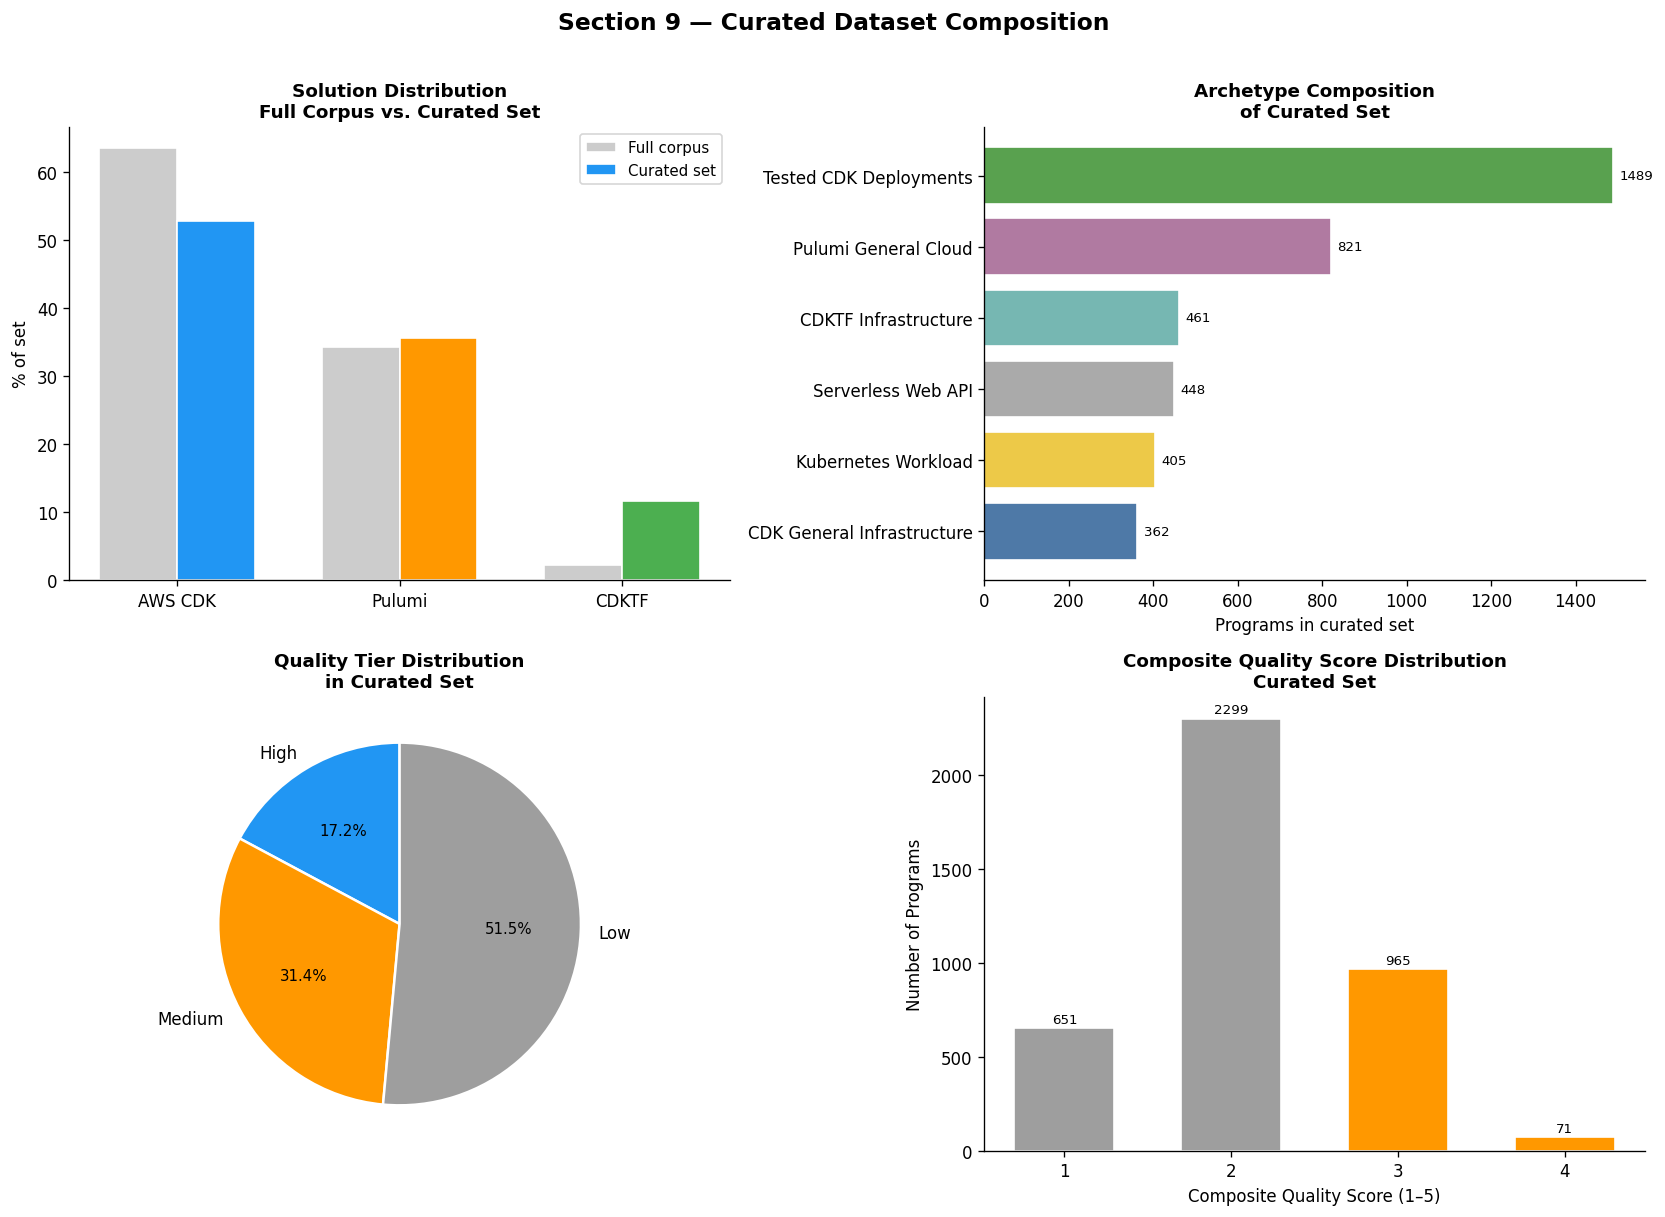

Saved: results/figures/s9_curated_dataset_composition.png


In [71]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Section 9 — Curated Dataset Composition", fontsize=14, fontweight="bold", y=1.01)

# Colour helpers
TIER_COLORS = {"High": "#2196F3", "Medium": "#FF9800", "Low": "#9E9E9E"}

# ── Top-left: solution distribution curated vs. full ──────────────────────
ax = axes[0, 0]
solutions = ["AWS CDK", "Pulumi", "CDKTF"]
full_pct    = [programs["solution"].value_counts(normalize=True).get(s, 0)*100 for s in solutions]
curated_pct = [curated_df["solution"].value_counts(normalize=True).get(s, 0)*100 for s in solutions]
x = np.arange(len(solutions))
w = 0.35
ax.bar(x - w/2, full_pct,    w, label="Full corpus", color="#ccc", edgecolor="white")
ax.bar(x + w/2, curated_pct, w, label="Curated set",
       color=[COLORS[s] for s in solutions], edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels(solutions, fontsize=10)
ax.set_ylabel("% of set", fontsize=10)
ax.set_title("Solution Distribution\nFull Corpus vs. Curated Set", fontsize=11, fontweight="bold")
ax.legend(fontsize=9); ax.spines[["top", "right"]].set_visible(False)

# ── Top-right: archetype composition of curated set ───────────────────────
ax = axes[0, 1]
arch_counts = curated_df["archetype"].value_counts()
arch_colors_list = [ARCHETYPE_COLORS.get(a, "#aaa") for a in arch_counts.index]
ax.barh(arch_counts.index, arch_counts.values, color=arch_colors_list, edgecolor="white")
ax.invert_yaxis()
ax.set_xlabel("Programs in curated set", fontsize=10)
ax.set_title("Archetype Composition\nof Curated Set", fontsize=11, fontweight="bold")
for i, (idx, val) in enumerate(arch_counts.items()):
    ax.text(val + 15, i, str(val), va="center", fontsize=8)
ax.spines[["top", "right"]].set_visible(False)

# ── Bottom-left: quality tier pie ─────────────────────────────────────────
ax = axes[1, 0]
tier_order = ["High", "Medium", "Low"]
tier_vals  = [int((curated_df["quality_tier"] == t).sum()) for t in tier_order]
tier_clrs  = [TIER_COLORS[t] for t in tier_order]
wedges, texts, autotexts = ax.pie(
    tier_vals, labels=tier_order, colors=tier_clrs,
    autopct="%1.1f%%", startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=1.5),
)
for at in autotexts:
    at.set_fontsize(9)
ax.set_title("Quality Tier Distribution\nin Curated Set", fontsize=11, fontweight="bold")

# ── Bottom-right: composite score histogram ───────────────────────────────
ax = axes[1, 1]
score_counts = curated_df["quality_score"].value_counts().sort_index()
bar_colors = ["#9E9E9E", "#9E9E9E", "#FF9800", "#FF9800", "#2196F3", "#2196F3"]
ax.bar(score_counts.index, score_counts.values,
       color=bar_colors[:len(score_counts)], edgecolor="white", width=0.6)
ax.set_xlabel("Composite Quality Score (1–5)", fontsize=10)
ax.set_ylabel("Number of Programs", fontsize=10)
ax.set_title("Composite Quality Score Distribution\nCurated Set", fontsize=11, fontweight="bold")
ax.set_xticks(score_counts.index)
for xi, yi in zip(score_counts.index, score_counts.values):
    ax.text(xi, yi + 30, str(yi), ha="center", fontsize=8)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(folder_path + "results/figures/s9_curated_dataset_composition.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: results/figures/s9_curated_dataset_composition.png")

### 9.4 Synthesis Findings

**Curated dataset at a glance**

The three-stage quality-tier pipeline selects **3,986 programs** across all 10 structural archetypes.
The curated set substantially reshapes the quality distribution compared to the raw corpus:

| Property | Full corpus | Curated set | Change |
|---|---|---|---|
| Total programs | 37,712 | 3,986 | — |
| Quality tier High | 1.8% | **17.2%** (685) | +15.4 pp |
| Quality tier Medium | 23.2% | **31.4%** (1,250) | +8.2 pp |
| Quality tier Low | 75.0% | **51.5%** (2,051) | −23.5 pp |
| AWS CDK share | 63.5% | 53.0% | reduced |
| Pulumi share | 34.3% | 35.4% | approx. retained |
| CDKTF share | 2.2% | 11.6% | +5x boost |
| Description coverage | ~33% | 24.0% | tradeoff with High/Med priority |
| Multi-service programs | ~1.2% | 11.1% | +9x |
| Mean quality score | — | 2.11 / 5 | (vs. 1.79 in gap-only strategy) |

**How the three stages interact**

*Stage 1 — All High programs (685)*: The corpus has only 685 High programs (n\_test\_files ≥ 2), concentrated overwhelmingly in Cluster 6 (Tested CDK Deployments: 602) with smaller contributions from CDKTF (28), Kubernetes (16), Pulumi (33), and others (6).  Taking all of them inflates the High fraction from 1.8% to 17.2% without any selection bias.

*Stage 2 — 1,250 Medium programs*: Sorting Medium programs by (gap\_score DESC, quality\_score DESC) first exhausts the 363 Medium programs across the nine rarer archetypes (CDKTF, Kubernetes, Serverless, Pulumi sub-clusters), then draws 887 programs from Cluster 6's 8,387 Medium pool to reach the 1,250 target.  This keeps 29% of the Medium budget in diverse archetypes.

*Stage 3 — ~2,051 Low programs*: Gap-weighted per-cluster sampling allocates Low budget proportionally to (1 + gap\_score).  The actual count falls short of the 3,065 Low-program target because four high-gap clusters (Pulumi General Cloud: 158 total, Complex Serverless: 26 Low, Multi-Cloud: 71 Low) are fully exhausted before their budget is filled — a genuine scarcity constraint, not a pipeline limitation.

**Trade-offs accepted**

- **Cluster 6 concentration** (37.4%): Achieving High/Medium fractions close to corpus-representative requires accepting that Cluster 6, which is the only source of the vast majority of tested programs, contributes heavily. The Low-tier stage partially offsets this by favouring high-gap clusters.
- **Description coverage** (24.0% vs. 33% in corpus): Prioritising High/Medium programs draws in more CDK programs (near-zero description coverage), slightly lowering the overall description fraction.  Pulumi programs still form 35.4% of the curated set and carry 98.5% description coverage within that slice.

**Next steps for downstream fine-tuning**

The curated set is ready as a candidate pool.  Recommended downstream filters before fine-tuning:
1. For CDK/CDKTF programs without descriptions: generate synthetic NL prompts via repository README extraction or commit message summarisation.
2. Apply a static-analysis correctness check (e.g., `cdk synth` / `pulumi preview --dry-run`) to validate the High/Medium programs before using them as positive training examples.
3. Source-code parsing to replace metadata-only service detection would unlock richer dependency graphs and enable a graph-topology quality filter for the next iteration of this pipeline.